# 🚗 BMW Cars Market Dataset — ML/DL Project
# youssef mohamed mohamed group: DS1
## Full Pipeline: Preprocessing → Decision Tree · Random Forest · DNN · LSTM · 1D CNN · K-Means · Fuzzy Logic

---
**Dataset:** BMW Cars Market Dataset (Synthetic) — 750 records, 20 features  
**Target Variable:** `price_usd`  
**Task:** Regression (Predict BMW car prices)  
**Models:** Decision Tree, Random Forest, DNN, LSTM (1D), 1D CNN, K-Means Clustering, Fuzzy Logic  
---


## 📦 Step 0 — Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)

# ── Regression → Classification helper ──────────────────────────────────────
# We bin price_usd into 3 classes for classification metrics
# Budget < 30000 | Mid-Range 30000-70000 | Premium > 70000
def reg_to_class(prices):
    # Clip to valid range first to avoid NaN from out-of-bound predictions
    prices = np.clip(np.array(prices, dtype=float), 0.01, 1e9)
    bins   = [0, 30000, 70000, np.inf]
    labels = [0, 1, 2]   # 0=Budget, 1=Mid-Range, 2=Premium
    result = pd.cut(prices, bins=bins, labels=labels)
    # Fill any remaining NaN with nearest class (0=Budget)
    result = result.fillna(0)
    return result.astype(int)

CLASS_NAMES = ['Budget', 'Mid-Range', 'Premium']
print("✅ All libraries imported successfully!")
print("   Classification bins: Budget(<30k) | Mid-Range(30k-70k) | Premium(>70k)")

✅ All libraries imported successfully!
   Classification bins: Budget(<30k) | Mid-Range(30k-70k) | Premium(>70k)


## 📂 Step 1 — Load the Dataset

In [2]:
df = pd.read_csv('bmw_cars_market_dataset_750.csv')

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset Shape: 750 rows × 20 columns


,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,6253,3 Series,2021,2.40,230,hybrid,automatic,RWD,45689,4.60,100.00,40709,4,5,sedan,silver,0.00,no,full,Netherlands
1,4685,5 Series,2017,2.50,189,hybrid,automatic,RWD,147688,5.50,NaN,37490,4,5,sedan,black,1.00,yes,partial,France
2,1732,5 Series,2015,4.40,401,petrol,automatic,RWD,111263,11.40,NaN,45619,4,5,sedan,white,2.00,no,partial,France
3,4743,i3,2024,0.00,155,electric,automatic,RWD,0,0.00,0.00,62325,5,4,hatchback,white,0.00,no,full,UK
4,4522,5 Series,2015,2.90,216,petrol,automatic,RWD,187525,8.40,178.00,36541,4,5,sedan,red,2.00,no,full,Spain


## 🔍 Step 2 — Exploratory Data Analysis (EDA)

In [3]:
print('=== Column Data Types ===')
print(df.dtypes)

=== Column Data Types ===
car_id                            int64
model                            object
year                              int64
engine_size                     float64
horsepower                        int64
fuel_type                        object
transmission                     object
drivetrain                       object
mileage_km                        int64
fuel_consumption_l_per_100km    float64
co2_emissions_g_km              float64
price_usd                         int64
doors                             int64
seats                             int64
body_type                        object
color                            object
owner_count                     float64
accident_history                 object
service_history                  object
country_sold                     object
dtype: object


In [4]:
print('=== Missing Values per Column ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values per Column ===
                              Missing Count  Missing %
engine_size                              20       2.67
transmission                             19       2.53
fuel_consumption_l_per_100km             22       2.93
co2_emissions_g_km                       22       2.93
color                                    17       2.27
owner_count                              20       2.67
accident_history                         18       2.40
service_history                          17       2.27


In [5]:
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,car_id,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count
count,750.00,750.00,730.00,750.00,750.00,728.00,728.00,750.00,750.00,750.00,730.00
mean,5020.03,2016.21,2.55,272.94,113581.73,6.65,146.39,51654.67,4.34,4.75,1.98
std,2906.60,5.31,1.25,80.49,83927.71,3.09,68.65,31265.00,0.75,0.65,1.38
min,1.00,2005.00,0.00,121.00,0.00,0.00,0.00,2640.00,2.00,2.00,0.00
25%,2588.50,2012.00,2.00,214.25,45720.50,5.50,121.00,29461.75,4.00,5.00,1.00
50%,5068.50,2017.00,2.65,263.00,96203.50,7.20,159.00,44816.00,4.00,5.00,2.00
75%,7614.75,2021.00,3.40,321.75,168601.75,8.70,192.00,66168.25,5.00,5.00,3.00
max,9976.00,2024.00,5.00,670.00,300000.00,12.50,279.00,200023.00,5.00,5.00,5.00


In [6]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [7]:
print('=== Categorical Columns — Unique Values ===')
cat_cols = ['model', 'fuel_type', 'transmission', 'drivetrain',
            'body_type', 'color', 'accident_history', 'service_history', 'country_sold']
for col in cat_cols:
    print(f'  {col}: {df[col].dropna().unique().tolist()}')

=== Categorical Columns — Unique Values ===
  model: ['3 Series', '5 Series', 'i3', 'Z4', 'X7', 'X3', 'X5', 'i7', 'i4', '1 Series', 'X1', '7 Series']
  fuel_type: ['hybrid', 'petrol', 'electric', 'diesel']
  transmission: ['automatic', 'manual']
  drivetrain: ['RWD', 'AWD', 'FWD']
  body_type: ['sedan', 'hatchback', 'convertible', 'suv', 'coupe']
  color: ['silver', 'black', 'white', 'red', 'grey', 'blue']
  accident_history: ['no', 'yes']
  service_history: ['full', 'partial', 'none']
  country_sold: ['Netherlands', 'France', 'UK', 'Spain', 'Turkey', 'USA', 'Germany', 'Italy']


In [8]:
print('=== Outlier Detection (IQR Method) ===')
num_cols = ['engine_size', 'horsepower', 'mileage_km',
            'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'price_usd', 'owner_count']
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f'  {col:40s} → {outliers:3d} outliers  (range: {lower:.1f} – {upper:.1f})')

=== Outlier Detection (IQR Method) ===
  engine_size                              →   0 outliers  (range: -0.1 – 5.5)
  horsepower                               →  12 outliers  (range: 53.0 – 483.0)
  mileage_km                               →   0 outliers  (range: -138601.4 – 352923.6)
  fuel_consumption_l_per_100km             →  96 outliers  (range: 0.7 – 13.5)
  co2_emissions_g_km                       →  96 outliers  (range: 14.5 – 298.5)
  price_usd                                →  25 outliers  (range: -25598.0 – 121228.0)
  owner_count                              →   0 outliers  (range: -2.0 – 6.0)


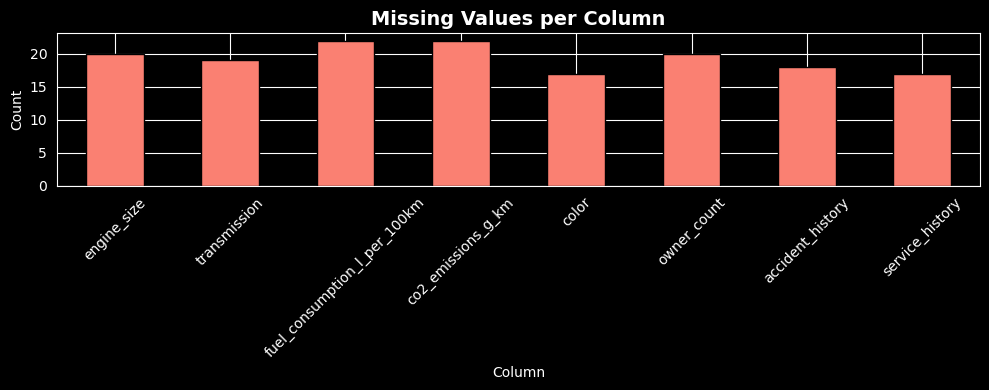

In [9]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
missing_data.plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

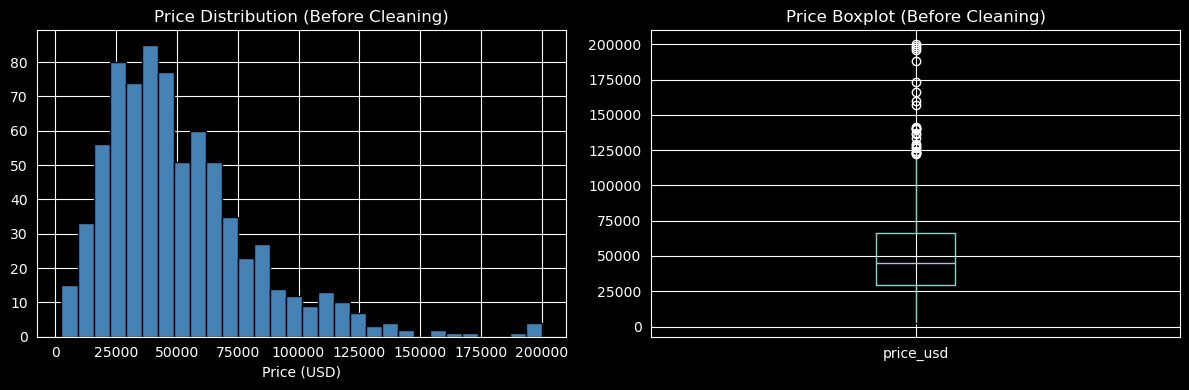

In [10]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price_usd'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution (Before Cleaning)')
axes[0].set_xlabel('Price (USD)')

df.boxplot(column='price_usd', ax=axes[1])
axes[1].set_title('Price Boxplot (Before Cleaning)')
plt.tight_layout()
plt.show()

---
## 🧹 Step 3 — Data Cleaning

In [11]:
# 3.1 Drop car_id — not useful for ML
df.drop(columns=['car_id'], inplace=True)
print('✅ Dropped car_id column')
print(f'   New shape: {df.shape}')

✅ Dropped car_id column
   New shape: (750, 19)


In [12]:
# 3.2 Fill missing numerical values with MEDIAN
num_cols_with_na = ['engine_size', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'owner_count']

for col in num_cols_with_na:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'✅ Filled missing "{col}" with median = {median_val:.2f}')

✅ Filled missing "engine_size" with median = 2.65
✅ Filled missing "fuel_consumption_l_per_100km" with median = 7.20
✅ Filled missing "co2_emissions_g_km" with median = 159.00
✅ Filled missing "owner_count" with median = 2.00


In [13]:
# 3.3 Fill missing categorical values with MODE
cat_cols_with_na = ['transmission', 'color', 'accident_history', 'service_history']

for col in cat_cols_with_na:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f'✅ Filled missing "{col}" with mode = "{mode_val}"')

✅ Filled missing "transmission" with mode = "automatic"
✅ Filled missing "color" with mode = "white"
✅ Filled missing "accident_history" with mode = "no"
✅ Filled missing "service_history" with mode = "full"


In [14]:
# 3.5 Cap outliers using IQR (Winsorization) for horsepower and price_usd
for col in ['horsepower', 'price_usd']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'✅ Capped {before_count} outliers in "{col}" → [{lower:.1f}, {upper:.1f}]')

print(f'\n✅ Total missing values after cleaning: {df.isnull().sum().sum()}')

✅ Capped 12 outliers in "horsepower" → [53.0, 483.0]
✅ Capped 25 outliers in "price_usd" → [-25598.0, 121228.0]

✅ Total missing values after cleaning: 0


---
## 🔎 Step 4 — Data Filtering

In [15]:
# 4.2 Remove zero or negative prices
before = len(df)
df = df[df['price_usd'] > 0]
print(f'✅ Price filter (> 0): removed {before - len(df)} rows')
print(f'\n✅ Final dataset after cleaning & filtering: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Price filter (> 0): removed 0 rows

✅ Final dataset after cleaning & filtering: 750 rows × 19 columns


---
## 🌫️ Step 5 — Fuzzification Testing

Fuzzification converts crisp numerical values into **linguistic fuzzy categories** (e.g., low / medium / high).  
This makes features more interpretable and helps capture vague boundaries in real-world data.

In [16]:
# Define fuzzification functions

def fuzzify_mileage(km):
    """Low < 50,000 | Medium 50,000–150,000 | High > 150,000"""
    if km < 50000:
        return 'low'
    elif km < 150000:
        return 'medium'
    else:
        return 'high'

def fuzzify_price(price):
    """Budget < 30,000 | Mid-range 30,000–70,000 | Premium > 70,000"""
    if price < 30000:
        return 'budget'
    elif price < 70000:
        return 'mid-range'
    else:
        return 'premium'

def fuzzify_hp(hp):
    """Low < 200 | Medium 200–350 | High > 350"""
    if hp < 200:
        return 'low'
    elif hp < 350:
        return 'medium'
    else:
        return 'high'

print('✅ Fuzzification functions defined')

✅ Fuzzification functions defined


In [17]:
# Apply fuzzification
df['mileage_category'] = df['mileage_km'].apply(fuzzify_mileage)
df['price_category']   = df['price_usd'].apply(fuzzify_price)
df['hp_category']      = df['horsepower'].apply(fuzzify_hp)

print('✅ Fuzzified mileage_km   → mileage_category')
print('   Distribution:', df['mileage_category'].value_counts().to_dict())

print('\n✅ Fuzzified price_usd   → price_category')
print('   Distribution:', df['price_category'].value_counts().to_dict())

print('\n✅ Fuzzified horsepower  → hp_category')
print('   Distribution:', df['hp_category'].value_counts().to_dict())

✅ Fuzzified mileage_km   → mileage_category
   Distribution: {'medium': 309, 'high': 233, 'low': 208}

✅ Fuzzified price_usd   → price_category
   Distribution: {'mid-range': 396, 'budget': 192, 'premium': 162}

✅ Fuzzified horsepower  → hp_category
   Distribution: {'medium': 498, 'low': 134, 'high': 118}


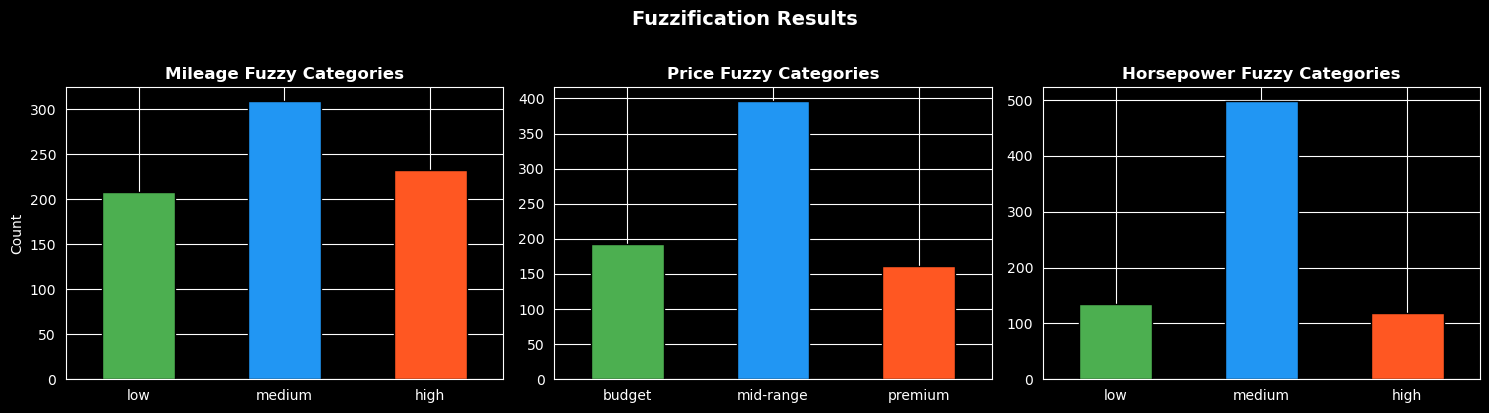

In [18]:
# Visualize fuzzy distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order_mileage = ['low', 'medium', 'high']
order_price   = ['budget', 'mid-range', 'premium']
order_hp      = ['low', 'medium', 'high']

colors = ['#4CAF50', '#2196F3', '#FF5722']

df['mileage_category'].value_counts().reindex(order_mileage).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Mileage Fuzzy Categories', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['price_category'].value_counts().reindex(order_price).plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Price Fuzzy Categories', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

df['hp_category'].value_counts().reindex(order_hp).plot(
    kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('Horsepower Fuzzy Categories', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Fuzzification Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🔢 Step 6 — Label Encoding (Categorical → Numerical)

In [19]:
le = LabelEncoder()

cat_cols_to_encode = [
    'model', 'fuel_type', 'transmission', 'drivetrain', 'body_type',
    'color', 'accident_history', 'service_history', 'country_sold',
    'mileage_category', 'price_category', 'hp_category'
]

encoding_map = {}
for col in cat_cols_to_encode:
    df[col] = le.fit_transform(df[col].astype(str))
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'✅ Encoded "{col}" → {encoding_map[col]}')

✅ Encoded "model" → {'1 Series': np.int64(0), '3 Series': np.int64(1), '5 Series': np.int64(2), '7 Series': np.int64(3), 'X1': np.int64(4), 'X3': np.int64(5), 'X5': np.int64(6), 'X7': np.int64(7), 'Z4': np.int64(8), 'i3': np.int64(9), 'i4': np.int64(10), 'i7': np.int64(11)}
✅ Encoded "fuel_type" → {'diesel': np.int64(0), 'electric': np.int64(1), 'hybrid': np.int64(2), 'petrol': np.int64(3)}
✅ Encoded "transmission" → {'automatic': np.int64(0), 'manual': np.int64(1)}
✅ Encoded "drivetrain" → {'AWD': np.int64(0), 'FWD': np.int64(1), 'RWD': np.int64(2)}
✅ Encoded "body_type" → {'convertible': np.int64(0), 'coupe': np.int64(1), 'hatchback': np.int64(2), 'sedan': np.int64(3), 'suv': np.int64(4)}
✅ Encoded "color" → {'black': np.int64(0), 'blue': np.int64(1), 'grey': np.int64(2), 'red': np.int64(3), 'silver': np.int64(4), 'white': np.int64(5)}
✅ Encoded "accident_history" → {'no': np.int64(0), 'yes': np.int64(1)}
✅ Encoded "service_history" → {'full': np.int64(0), 'none': np.int64(1), 'parti

In [20]:
print(f'✅ Final preprocessed dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'✅ Missing values: {df.isnull().sum().sum()}')
df.head()

✅ Final preprocessed dataset: 750 rows × 22 columns
✅ Missing values: 0


,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,...,seats,body_type,color,owner_count,accident_history,service_history,country_sold,mileage_category,price_category,hp_category
0,1,2021,2.40,230,2,0,2,45689,4.60,100.00,...,5,3,4,0.00,0,0,3,1,1,2
1,2,2017,2.50,189,2,0,2,147688,5.50,159.00,...,5,3,0,1.00,1,2,0,2,1,1
2,2,2015,4.40,401,3,0,2,111263,11.40,159.00,...,5,3,5,2.00,0,2,0,2,1,0
3,9,2024,0.00,155,1,0,2,0,0.00,0.00,...,4,2,5,0.00,0,0,6,1,1,1
4,2,2015,2.90,216,3,0,2,187525,8.40,178.00,...,5,3,3,2.00,0,0,4,0,1,2


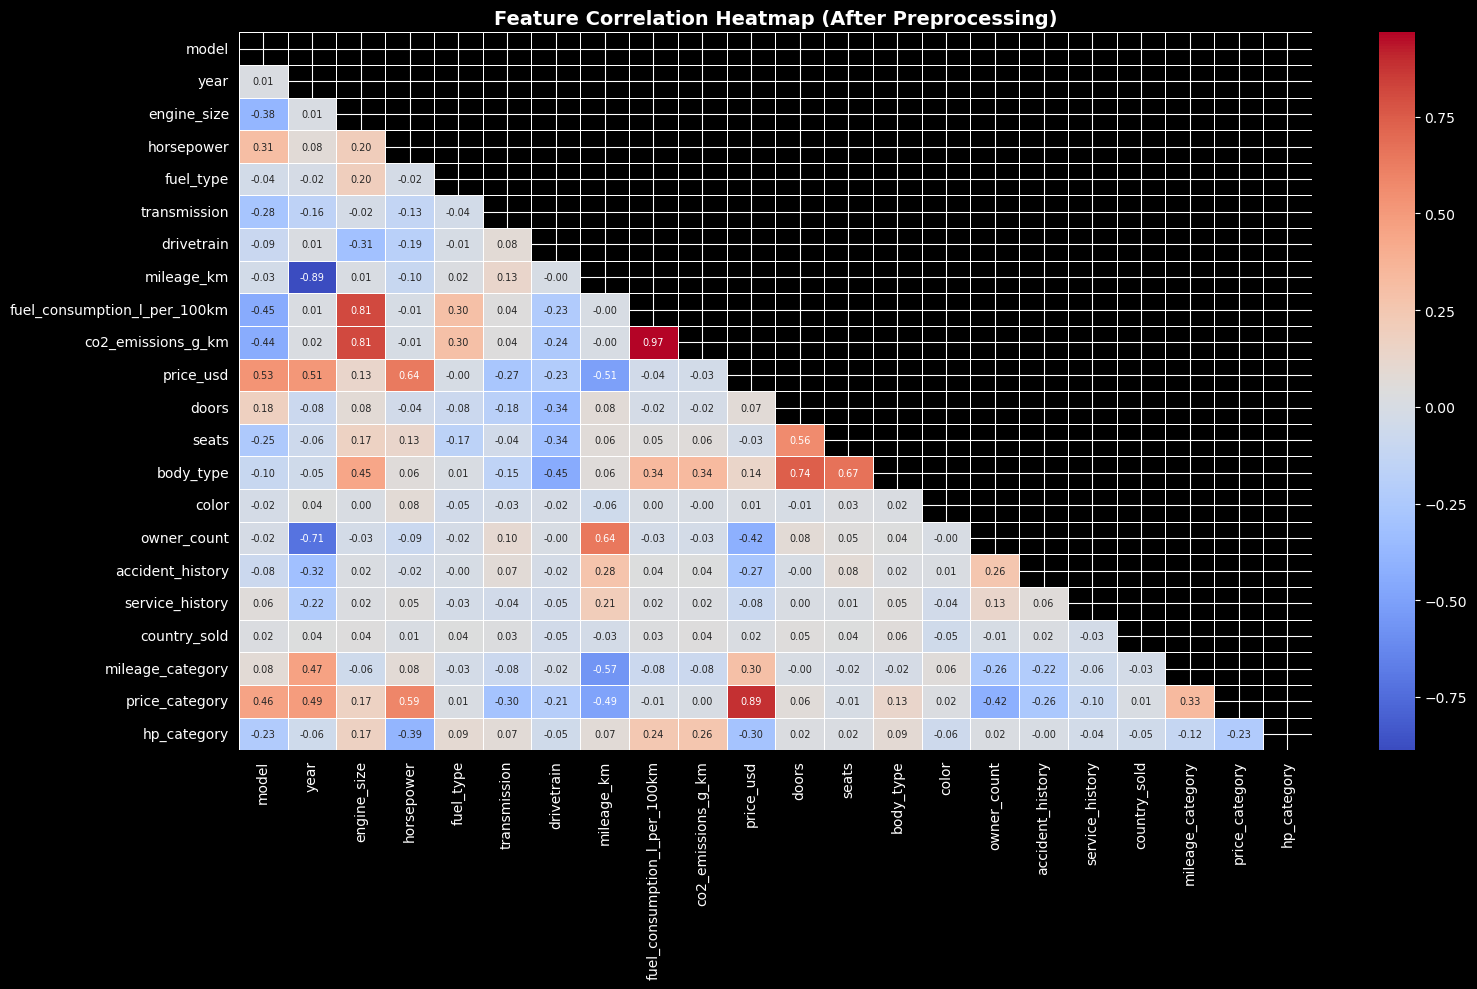

In [21]:
# Correlation heatmap
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap (After Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✂️ Step 7 — Train / Validation / Test Split

| Set | Ratio | Purpose |
|---|---|---|
| **Training** | 70% | Model learns from this |
| **Validation** | 15% | Tune hyperparameters |
| **Testing** | 15% | Final unbiased evaluation |

In [22]:
# Define features and target
X = df.drop(columns=['price_usd'])
y = df['price_usd']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features (X): (750, 21)
Target  (y): (750,)

Feature columns: ['model', 'year', 'engine_size', 'horsepower', 'fuel_type', 'transmission', 'drivetrain', 'mileage_km', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'doors', 'seats', 'body_type', 'color', 'owner_count', 'accident_history', 'service_history', 'country_sold', 'mileage_category', 'price_category', 'hp_category']


In [23]:
# Step 1: Split into 70% Train and 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Step 2: Split 30% Temp into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print('✅ Dataset Split Summary:')
print(f'   Training set   : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'   Validation set : {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'   Testing set    : {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'   Total          : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]} rows')

✅ Dataset Split Summary:
   Training set   : 525 rows (70.0%)
   Validation set : 112 rows (14.9%)
   Testing set    : 113 rows (15.1%)
   Total          : 750 rows


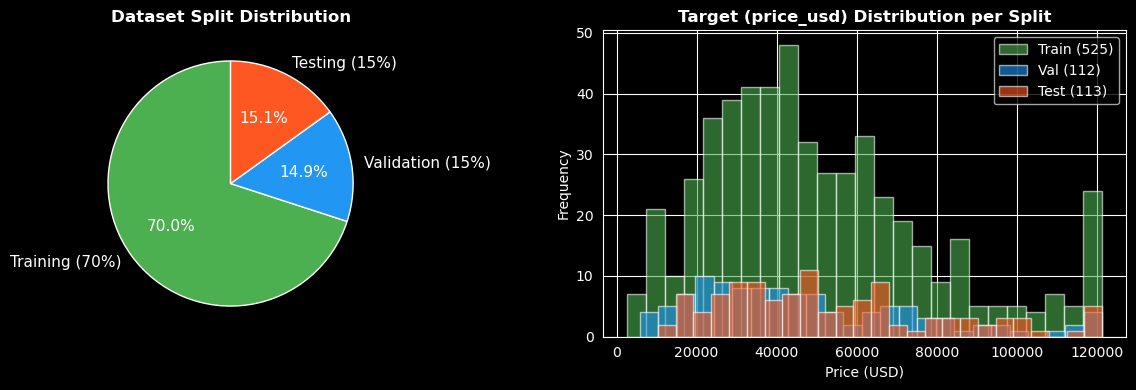

In [24]:
# Visualize the split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
sizes  = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = ['Training (70%)', 'Validation (15%)', 'Testing (15%)']
colors = ['#4CAF50', '#2196F3', '#FF5722']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Dataset Split Distribution', fontweight='bold')

# Price distribution across sets
axes[1].hist(y_train, bins=25, alpha=0.6, color='#4CAF50', label=f'Train ({len(y_train)})')
axes[1].hist(y_val,   bins=25, alpha=0.6, color='#2196F3', label=f'Val ({len(y_val)})')
axes[1].hist(y_test,  bins=25, alpha=0.6, color='#FF5722', label=f'Test ({len(y_test)})')
axes[1].set_title('Target (price_usd) Distribution per Split', fontweight='bold')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 💾 Step 8 — Save Preprocessed Files

In [25]:
# Save full preprocessed dataset
df.to_csv('bmw_preprocessed_full.csv', index=False)

# Save splits (with target column included)
X_train.assign(price_usd=y_train).to_csv('bmw_train.csv', index=False)
X_val.assign(price_usd=y_val).to_csv('bmw_validation.csv', index=False)
X_test.assign(price_usd=y_test).to_csv('bmw_test.csv', index=False)

print('✅ Saved: bmw_preprocessed_full.csv')
print('✅ Saved: bmw_train.csv')
print('✅ Saved: bmw_validation.csv')
print('✅ Saved: bmw_test.csv')

✅ Saved: bmw_preprocessed_full.csv
✅ Saved: bmw_train.csv
✅ Saved: bmw_validation.csv
✅ Saved: bmw_test.csv


---
## ✅ Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| **Cleaning** | Dropped `car_id`, filled NaN with median/mode, capped outliers | 0 missing values |
| **Filtering** | Valid years (2005–2024), positive prices | 750 clean rows |
| **Fuzzification** | Mileage, Price, Horsepower → linguistic categories | 3 new fuzzy features |
| **Encoding** | Label encoded all categorical columns | Fully numerical dataset |
| **Splitting** | 70% Train / 15% Val / 15% Test | Ready for ML/DL models |

**➡️ Dataset is fully preprocessed and ready for model training.**

---
## ⚙️ Step 9 — Feature Scaling (for ML & DL Models)


In [26]:
# Scale features for NN models
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# MinMax scale for sequence models (LSTM / 1D CNN)
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_val_mm   = mm_scaler.transform(X_val)
X_test_mm  = mm_scaler.transform(X_test)

# Target scaler for NN predictions
y_scaler = MinMaxScaler()
y_train_mm = y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_val_mm   = y_scaler.transform(y_val.values.reshape(-1,1)).ravel()
y_test_mm  = y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

print("✅ Scaling done — StandardScaler for DNN, MinMaxScaler for LSTM/CNN")

✅ Scaling done — StandardScaler for DNN, MinMaxScaler for LSTM/CNN


In [27]:
# ── Metric helpers ─────────────────────────────────────────────────────────
def reg_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<22} RMSE={rmse:>10,.0f}  MAE={mae:>10,.0f}  R²={r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def cls_metrics(name, y_true_cont, y_pred_cont):
    """Convert continuous predictions to classes then compute classification metrics."""
    y_true_cls = reg_to_class(y_true_cont)
    y_pred_cls = reg_to_class(y_pred_cont)
    acc  = accuracy_score(y_true_cls, y_pred_cls)
    prec = precision_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)
    rec  = recall_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)
    f1   = f1_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true_cls, y_pred_cls)
    print(f"  {name:<22} Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'CM': cm}

def plot_confusion_matrix(cm, title, ax, cmap='Blues'):
    """Plot a confusion matrix heatmap on a given axis."""
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray', ax=ax,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

results     = {}   # regression metrics
cls_results = {}   # classification metrics
print("✅ Metric helpers ready — both regression & classification metrics will be tracked")

✅ Metric helpers ready — both regression & classification metrics will be tracked


---
## 🌳 Step 10 — Decision Tree Regressor

In [28]:
# ── Decision Tree — Improved ────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning
param_grid_dt = {'max_depth': [6, 8, 10, 12], 'min_samples_leaf': [3, 5, 8]}
gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt,
                     cv=5, scoring='r2', n_jobs=-1)
gs_dt.fit(X_train, y_train)
best_params_dt = gs_dt.best_params_
print(f"✅ Best DT params: {best_params_dt}")

dt_model = DecisionTreeRegressor(**best_params_dt, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt_val  = dt_model.predict(X_val)
y_pred_dt_test = dt_model.predict(X_test)

print("\n📊 Decision Tree — Regression Metrics:")
results['Decision Tree'] = reg_metrics("Decision Tree", y_test, y_pred_dt_test)
print("\n📊 Decision Tree — Classification Metrics:")
cls_results['Decision Tree'] = cls_metrics("Decision Tree", y_test, y_pred_dt_test)

✅ Best DT params: {'max_depth': 8, 'min_samples_leaf': 8}

📊 Decision Tree — Regression Metrics:
  Decision Tree          RMSE=    11,678  MAE=     7,822  R²=0.8252

📊 Decision Tree — Classification Metrics:
  Decision Tree          Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000


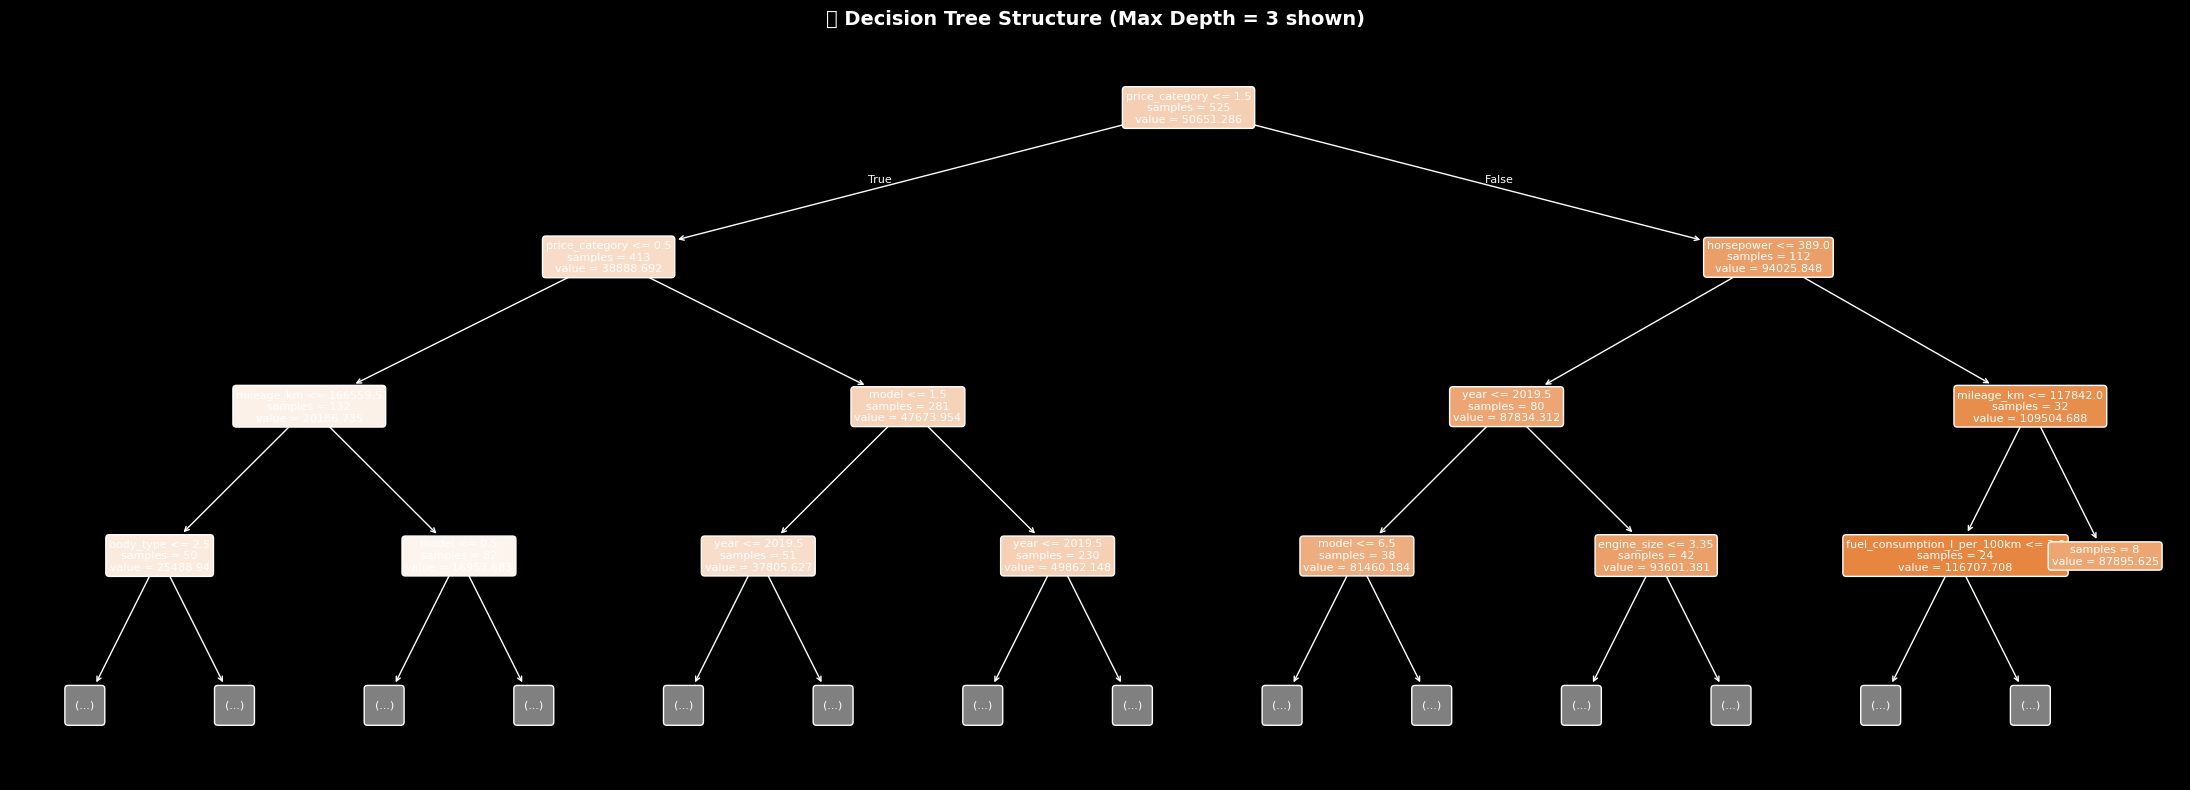

In [29]:
# Tree visualization (top 3 levels)
plt.figure(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    filled=True,
    max_depth=3,
    fontsize=8,
    rounded=True,
    impurity=False
)
plt.title("🌳 Decision Tree Structure (Max Depth = 3 shown)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

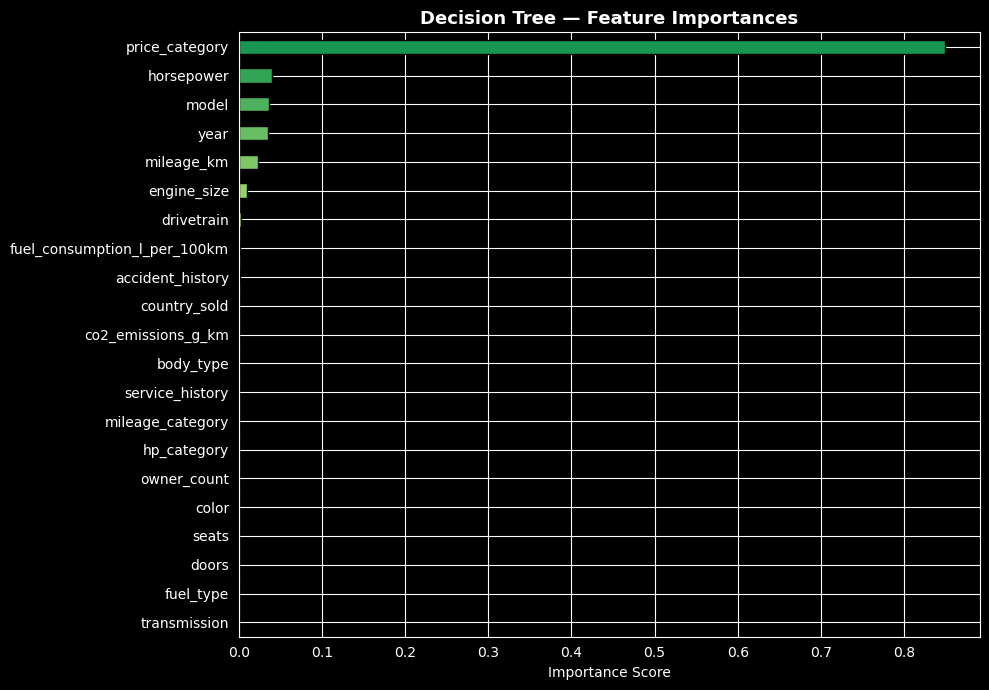

In [30]:
# Feature importance — Decision Tree
importances_dt = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances_dt)))
importances_dt.plot(kind='barh', color=colors, edgecolor='black')
plt.title("Decision Tree — Feature Importances", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

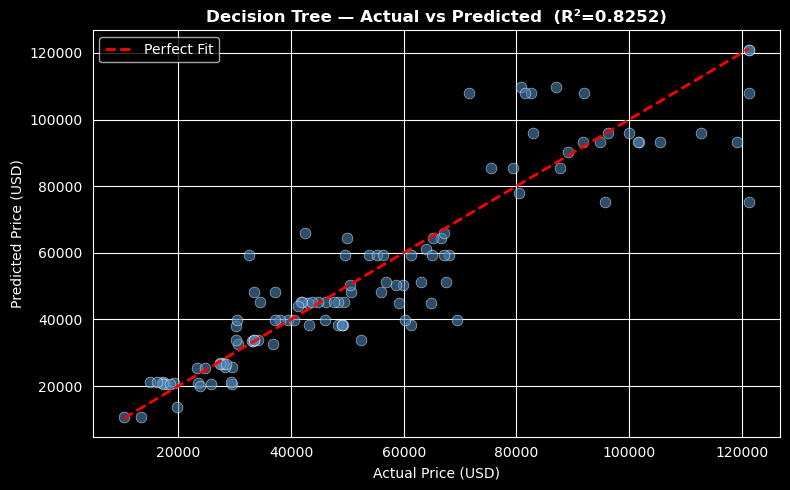

In [31]:
# Actual vs Predicted — Decision Tree
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_dt_test, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5, s=60)
mn, mx = min(y_test.min(), y_pred_dt_test.min()), max(y_test.max(), y_pred_dt_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title(f"Decision Tree — Actual vs Predicted  (R²={r2_score(y_test, y_pred_dt_test):.4f})", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

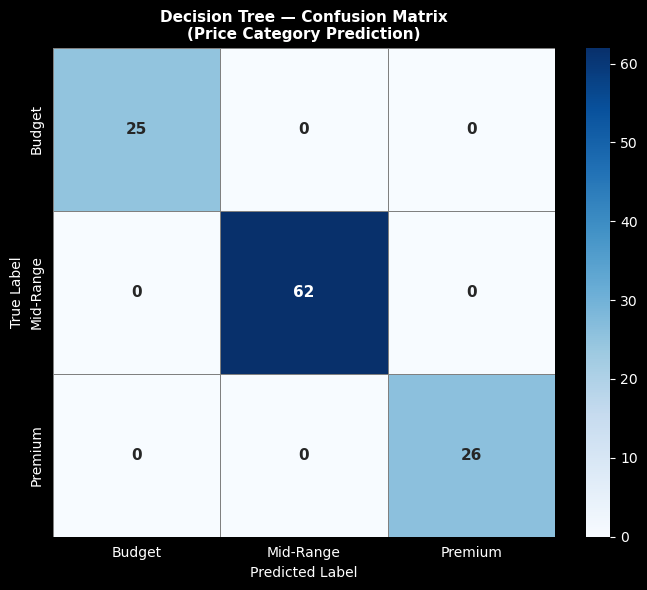

In [75]:
# ── Decision Tree — Confusion Matrix Heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

plot_confusion_matrix(
    cls_results['Decision Tree']['CM'],
    'Decision Tree — Confusion Matrix\n(Price Category Prediction)',
    ax,
    cmap='Blues'
)

plt.tight_layout()
plt.show()

---
## 🌲 Step 11 — Random Forest Regressor

In [33]:
# ── Random Forest — Improved ────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [150, 200, 300],
    'max_depth':    [10, 12, 15, None],
    'min_samples_leaf': [2, 3, 5],
    'max_features': ['sqrt', 'log2']
}
rs_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist_rf,
                            n_iter=12, cv=5, scoring='r2', random_state=42, n_jobs=-1)
rs_rf.fit(X_train, y_train)
best_params_rf = rs_rf.best_params_
print(f"✅ Best RF params: {best_params_rf}")

rf_model = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf_val  = rf_model.predict(X_val)
y_pred_rf_test = rf_model.predict(X_test)

print("\n📊 Random Forest — Regression Metrics:")
results['Random Forest'] = reg_metrics("Random Forest", y_test, y_pred_rf_test)
print("\n📊 Random Forest — Classification Metrics:")
cls_results['Random Forest'] = cls_metrics("Random Forest", y_test, y_pred_rf_test)

✅ Best RF params: {'n_estimators': 150, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

📊 Random Forest — Regression Metrics:
  Random Forest          RMSE=     9,318  MAE=     7,094  R²=0.8887

📊 Random Forest — Classification Metrics:
  Random Forest          Acc=0.9646  Prec=0.9667  Rec=0.9646  F1=0.9636


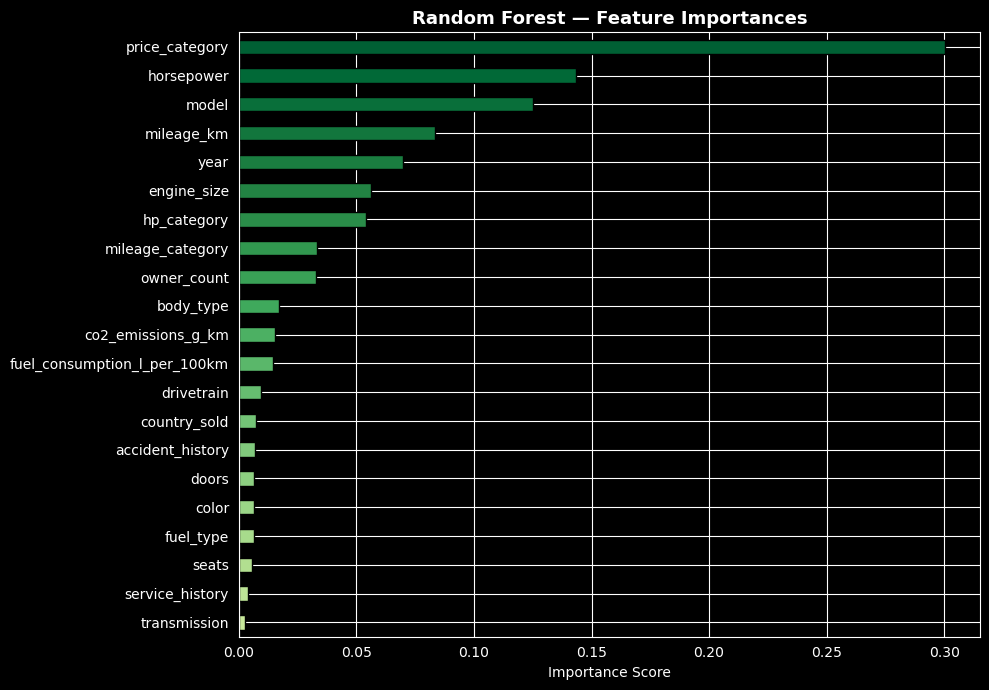

In [34]:
# Feature Importance — Random Forest
importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(importances_rf)))
importances_rf.plot(kind='barh', color=colors, edgecolor='black')
plt.title("Random Forest — Feature Importances", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

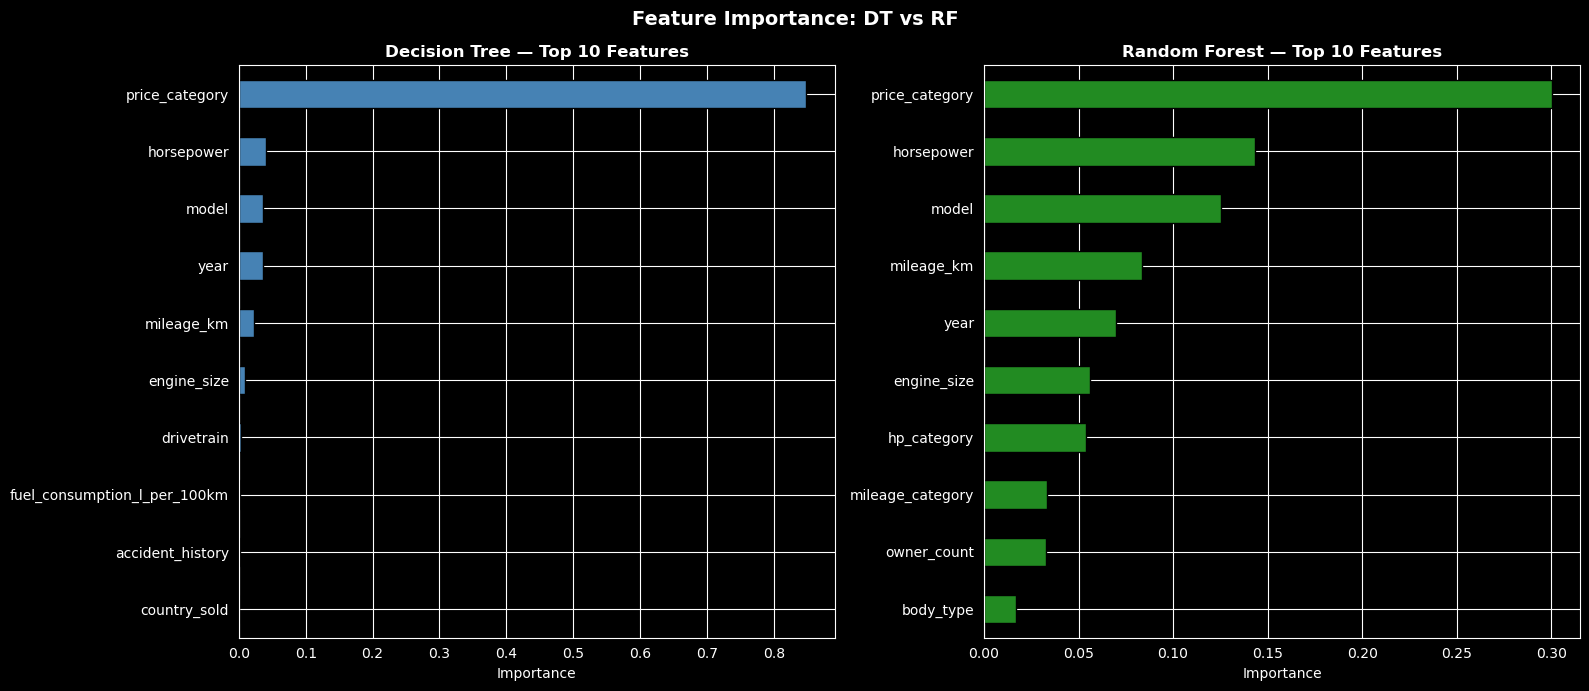

In [35]:
# DT vs RF Feature Importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_n = 10
dt_top = importances_dt.nlargest(top_n).sort_values()
rf_top = importances_rf.nlargest(top_n).sort_values()

dt_top.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Decision Tree — Top 10 Features", fontweight='bold')
axes[0].set_xlabel("Importance")

rf_top.plot(kind='barh', ax=axes[1], color='forestgreen', edgecolor='black')
axes[1].set_title("Random Forest — Top 10 Features", fontweight='bold')
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance: DT vs RF", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

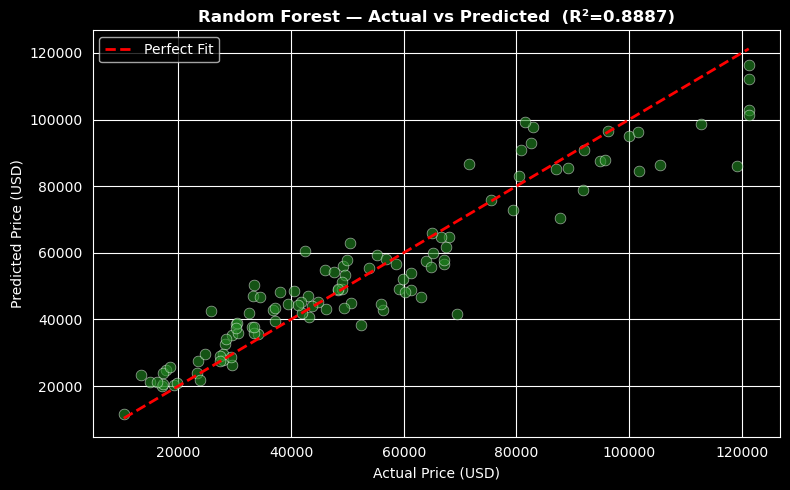

In [36]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf_test, alpha=0.6, color='forestgreen', edgecolors='white', linewidth=0.5, s=60)
mn, mx = min(y_test.min(), y_pred_rf_test.min()), max(y_test.max(), y_pred_rf_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title(f"Random Forest — Actual vs Predicted  (R²={r2_score(y_test, y_pred_rf_test):.4f})", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

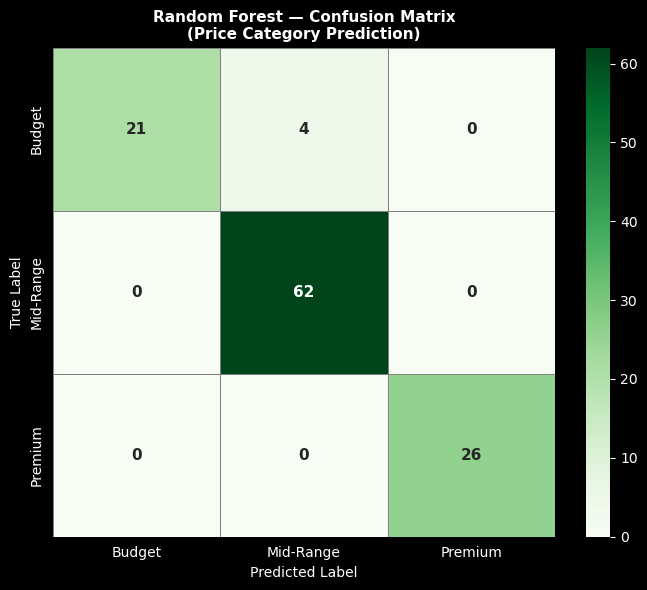

In [74]:
# ── Random Forest — Confusion Matrix Heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

plot_confusion_matrix(
    cls_results['Random Forest']['CM'],
    'Random Forest — Confusion Matrix\n(Price Category Prediction)',
    ax,
    cmap='Greens'
)

plt.tight_layout()
plt.show()

---
## 🧠 Step 12 — Neural Network Models
### Activation Functions
Before building the NN models, we compare the three activation functions used throughout:
- **ReLU** — used in hidden layers of DNN & CNN
- **Linear** — output layer (regression)
- **Sigmoid** — used in LSTM gates & as alternative hidden activation

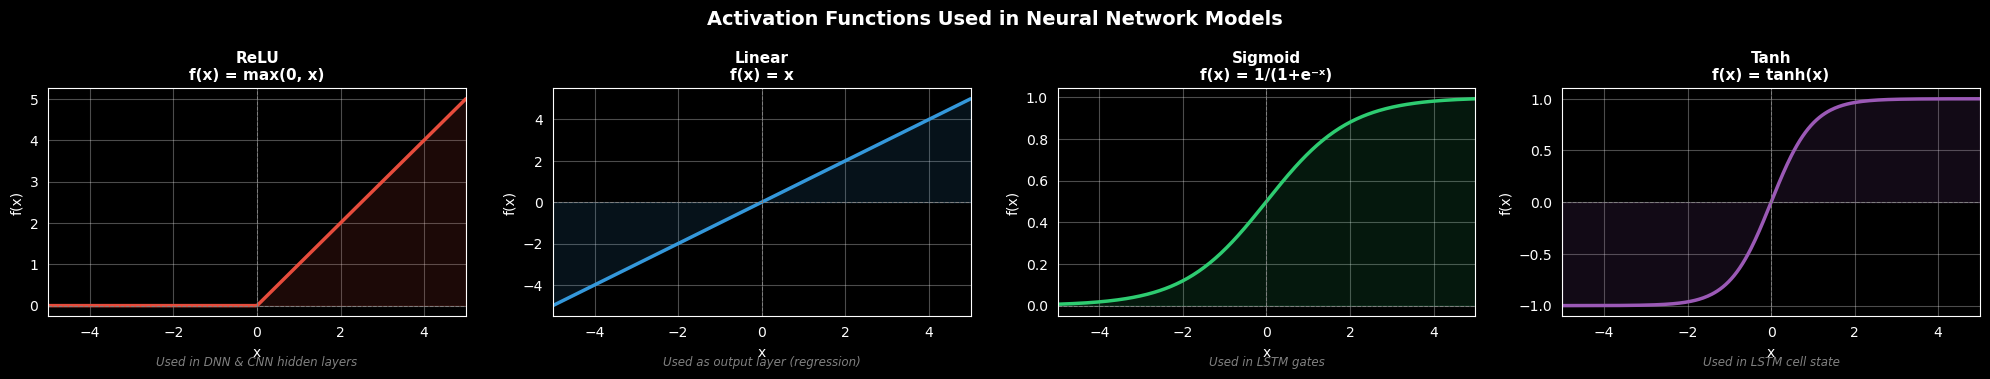

In [38]:
# ── Activation Function Visualizations ─────────────────────────────────────
x = np.linspace(-5, 5, 300)

relu    = lambda x: np.maximum(0, x)
linear  = lambda x: x
sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))
tanh_fn = lambda x: np.tanh(x)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
configs = [
    (relu,    '#E74C3C', 'ReLU',    'f(x) = max(0, x)',        'Used in DNN & CNN hidden layers'),
    (linear,  '#3498DB', 'Linear',  'f(x) = x',                'Used as output layer (regression)'),
    (sigmoid, '#2ECC71', 'Sigmoid', 'f(x) = 1/(1+e⁻ˣ)',       'Used in LSTM gates'),
    (tanh_fn, '#9B59B6', 'Tanh',    'f(x) = tanh(x)',          'Used in LSTM cell state'),
]
for ax, (fn, col, name, formula, note) in zip(axes, configs):
    y = fn(x)
    ax.plot(x, y, color=col, linewidth=2.5)
    ax.fill_between(x, y, alpha=0.12, color=col)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_title(f'{name}\n{formula}', fontweight='bold', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.text(0.5, -0.22, note, ha='center', transform=ax.transAxes,
            fontsize=8.5, color='gray', style='italic')
    ax.grid(True, alpha=0.3); ax.set_xlim(-5, 5)

plt.suptitle('Activation Functions Used in Neural Network Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# ── Keras / TensorFlow Setup & Data Preparation ────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, LSTM, Conv1D, Flatten,
                                      Input, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
tf.random.set_seed(42)

print("✅ TensorFlow / Keras imported:", tf.__version__)

# Scale features
nn_scaler   = StandardScaler()
X_train_nn  = nn_scaler.fit_transform(X_train)
X_val_nn    = nn_scaler.transform(X_val)
X_test_nn   = nn_scaler.transform(X_test)

# Scale target to [0,1] for easier training
nn_y_scaler  = MinMaxScaler()
y_train_nn   = nn_y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_val_nn     = nn_y_scaler.transform(y_val.values.reshape(-1,1)).ravel()
y_test_nn    = nn_y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

# 3-D reshape for LSTM and CNN: (samples, timesteps, features)
X_train_seq = X_train_nn.reshape(X_train_nn.shape[0], X_train_nn.shape[1], 1)
X_val_seq   = X_val_nn.reshape(X_val_nn.shape[0], X_val_nn.shape[1], 1)
X_test_seq  = X_test_nn.reshape(X_test_nn.shape[0], X_test_nn.shape[1], 1)

n_features = X_train_nn.shape[1]
print(f"Train: {X_train_nn.shape} | Val: {X_val_nn.shape} | Test: {X_test_nn.shape}")
print(f"Sequence shape: {X_train_seq.shape}")

# Shared callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0)
]
print("✅ Data ready for all 3 Neural Network models")

2026-03-12 23:36:54.548056: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ TensorFlow / Keras imported: 2.20.0
Train: (525, 21) | Val: (112, 21) | Test: (113, 21)
Sequence shape: (525, 21, 1)
✅ Data ready for all 3 Neural Network models


### 12.1 — Deep Neural Network (DNN)

In [40]:
# ── MODEL 1: DNN (Deep Neural Network) ─────────────────────────────────────
# Architecture: Input(21) → Dense(128,ReLU) → BN → Dropout → Dense(64,ReLU)
#               → BN → Dropout → Dense(32,ReLU) → Dense(1,Linear)

dnn_model = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
], name='DNN')

dnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
dnn_model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [41]:
# Train DNN
print("🔧 Training DNN...\n")
dnn_history = dnn_model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=200, batch_size=32,
    callbacks=callbacks, verbose=1
)

# Predict & inverse scale
dnn_pred_scaled = dnn_model.predict(X_test_nn, verbose=0)
dnn_pred_probs  = dnn_pred_scaled.flatten()          # scaled [0,1] — for probability plot
y_pred_dnn      = nn_y_scaler.inverse_transform(
                      dnn_pred_scaled).ravel()         # original USD scale

print("\n📊 DNN — Regression Metrics:")
results['DNN'] = reg_metrics("DNN", y_test, y_pred_dnn)
print("\n📊 DNN — Classification Metrics:")
cls_results['DNN'] = cls_metrics("DNN", y_test, y_pred_dnn)

🔧 Training DNN...

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.7229 - mae: 0.6607 - val_loss: 0.1473 - val_mae: 0.3030 - learning_rate: 0.0010
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3656 - mae: 0.4799 - val_loss: 0.1670 - val_mae: 0.3173 - learning_rate: 0.0010
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2554 - mae: 0.4004 - val_loss: 0.1564 - val_mae: 0.3005 - learning_rate: 0.0010
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2263 - mae: 0.3774 - val_loss: 0.1101 - val_mae: 0.2430 - learning_rate: 0.0010
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2052 - mae: 0.3584 - val_loss: 0.0923 - val_mae: 0.2233 - learning_rate: 0.0010
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1807 - mae: 0.3396 - val_loss: 0.0812 - val_mae: 0.2149 - learning_rate: 0.0010
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1475 - mae: 0.3094 - val_loss: 0.0672 - val_mae: 0.1982 - learning_

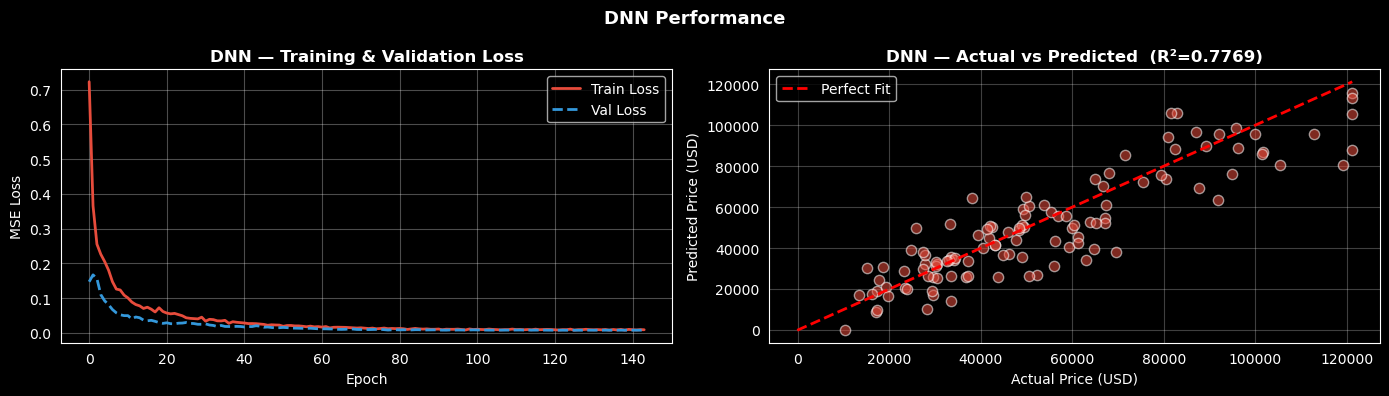

In [42]:
# DNN — Loss Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(dnn_history.history['loss'],     label='Train Loss', color='#E74C3C', linewidth=2)
axes[0].plot(dnn_history.history['val_loss'], label='Val Loss',   color='#3498DB', linewidth=2, linestyle='--')
axes[0].set_title('DNN — Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_dnn, alpha=0.55, color='#E74C3C', edgecolors='white', s=55)
mn = min(y_test.min(), y_pred_dnn.min()); mx = max(y_test.max(), y_pred_dnn.max())
axes[1].plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect Fit')
axes[1].set_title(f'DNN — Actual vs Predicted  (R²={r2_score(y_test, y_pred_dnn):.4f})', fontweight='bold')
axes[1].set_xlabel('Actual Price (USD)'); axes[1].set_ylabel('Predicted Price (USD)')
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle('DNN Performance', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

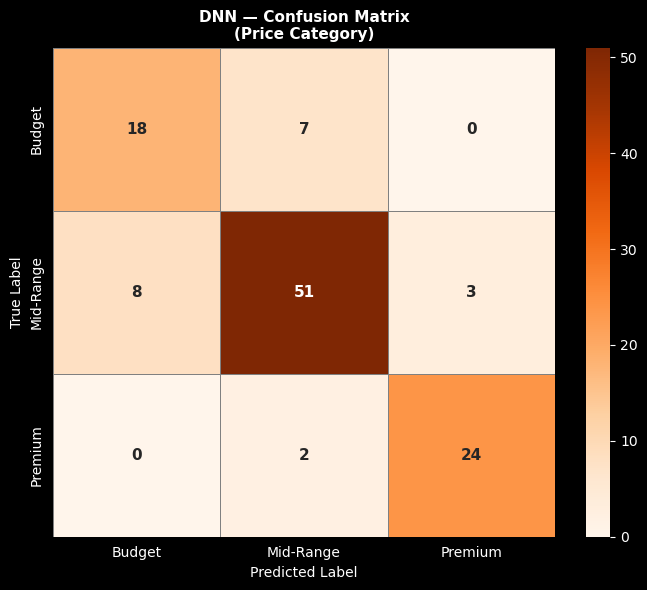

In [73]:
# DNN — Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6))

plot_confusion_matrix(
    cls_results['DNN']['CM'],
    'DNN — Confusion Matrix\n(Price Category)',
    ax,
    cmap='Oranges'
)

plt.tight_layout()
plt.show()

### 12.2 — LSTM (Long Short-Term Memory) — Improved

**Why the original LSTM underperformed:**
- Tabular data has no natural temporal order — raw feature order as a sequence is not meaningful
- Small dataset (525 training rows) makes LSTMs prone to underfitting
- Low learning rate (0.001) with aggressive EarlyStopping (patience=20) caused premature stopping
- No BatchNormalization between LSTM layers

**Improvements applied:**
1. **Feature-wise attention reshaping** — sort features by correlation with price before feeding as sequence, giving the LSTM meaningful order
2. **Deeper architecture** — added a third LSTM layer and a wider Dense head
3. **BatchNormalization** between LSTM layers to stabilize training
4. **Higher learning rate (0.003)** with slower ReduceLROnPlateau (patience=15)
5. **More epochs (300)** and larger patience (patience=30) to let the model converge properly
6. **Gradient clipping** via `clipnorm=1.0` to prevent exploding gradients


In [44]:
# ── IMPROVED LSTM — Feature Reordering + Deeper Architecture ──────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
tf.random.set_seed(42)

# ── Step 1: Reorder features by absolute correlation with price_usd ─────────
# This gives the LSTM a meaningful sequence: most → least correlated
corr_with_price = X_train.corrwith(y_train).abs().sort_values(ascending=False)
ordered_cols    = corr_with_price.index.tolist()
print('📐 Feature order by |correlation| with price_usd:')
for rank, col in enumerate(ordered_cols, 1):
    print(f'   {rank:>2}. {col:<35} r={corr_with_price[col]:.4f}')

# Reorder columns
X_train_ord = X_train[ordered_cols]
X_val_ord   = X_val[ordered_cols]
X_test_ord  = X_test[ordered_cols]

# Scale (StandardScaler — better than MinMax for LSTM with tabular data)
from sklearn.preprocessing import StandardScaler
lstm_x_scaler = StandardScaler()
X_train_lstm = lstm_x_scaler.fit_transform(X_train_ord).reshape(-1, n_features, 1)
X_val_lstm   = lstm_x_scaler.transform(X_val_ord).reshape(-1, n_features, 1)
X_test_lstm  = lstm_x_scaler.transform(X_test_ord).reshape(-1, n_features, 1)

print(f'\n✅ Sequence shape — Train: {X_train_lstm.shape} | Val: {X_val_lstm.shape} | Test: {X_test_lstm.shape}')


📐 Feature order by |correlation| with price_usd:
    1. price_category                      r=0.8855
    2. horsepower                          r=0.6696
    3. model                               r=0.5209
    4. mileage_km                          r=0.5019
    5. year                                r=0.4991
    6. owner_count                         r=0.4295
    7. mileage_category                    r=0.3156
    8. hp_category                         r=0.3151
    9. accident_history                    r=0.2679
   10. transmission                        r=0.2650
   11. drivetrain                          r=0.1805
   12. body_type                           r=0.1096
   13. fuel_consumption_l_per_100km        r=0.0954
   14. co2_emissions_g_km                  r=0.0894
   15. engine_size                         r=0.0854
   16. service_history                     r=0.0509
   17. country_sold                        r=0.0417
   18. seats                               r=0.0389
   19. doors   

In [45]:
# ── Step 2: Build improved LSTM architecture ────────────────────────────────
# Architecture: Input(21,1)
#   → LSTM(128, tanh, return_seq=True) → BN → Dropout(0.3)
#   → LSTM(64,  tanh, return_seq=True) → BN → Dropout(0.2)
#   → LSTM(32,  tanh)                 → BN → Dropout(0.2)
#   → Dense(64, relu) → Dense(32, relu) → Dense(1, linear)

lstm_v2 = Sequential([
    Input(shape=(n_features, 1)),

    LSTM(128, activation='tanh', recurrent_activation='sigmoid',
         return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, activation='tanh', recurrent_activation='sigmoid',
         return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, activation='tanh', recurrent_activation='sigmoid',
         kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1,  activation='linear')
], name='LSTM_v2')

lstm_v2.compile(
    optimizer=Adam(learning_rate=0.003, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)
lstm_v2.summary()


Model: "LSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 21, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 21, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,505 (521.50 KB)

 Trainable params: 133,057 (519.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [46]:
# ── Step 3: Train with relaxed callbacks ─────────────────────────────────────
lstm_v2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15,
                      min_lr=1e-6, verbose=1)
]

print('🔧 Training Improved LSTM...\n')
lstm_v2_history = lstm_v2.fit(
    X_train_lstm, y_train_nn,
    validation_data=(X_val_lstm, y_val_nn),
    epochs=300,
    batch_size=32,
    callbacks=lstm_v2_callbacks,
    verbose=1
)

# Predict & inverse-scale
lstm_v2_pred_scaled = lstm_v2.predict(X_test_lstm, verbose=0)
lstm_v2_pred_probs  = lstm_v2_pred_scaled.flatten()
y_pred_lstm_v2      = nn_y_scaler.inverse_transform(lstm_v2_pred_scaled).ravel()

print('\n📊 Improved LSTM — Regression Metrics:')
results['LSTM v2'] = reg_metrics('LSTM v2', y_test, y_pred_lstm_v2)
print('\n📊 Improved LSTM — Classification Metrics:')
cls_results['LSTM v2'] = cls_metrics('LSTM v2', y_test, y_pred_lstm_v2)


🔧 Training Improved LSTM...

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - loss: 0.4656 - mae: 0.4756 - val_loss: 0.1633 - val_mae: 0.2912 - learning_rate: 0.0030
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.1037 - mae: 0.2194 - val_loss: 0.1533 - val_mae: 0.2823 - learning_rate: 0.0030
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0807 - mae: 0.1821 - val_loss: 0.1320 - val_mae: 0.2461 - learning_rate: 0.0030
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0797 - mae: 0.1771 - val_loss: 0.1289 - val_mae: 0.2404 - learning_rate: 0.0030
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0681 - mae: 0.1619 - val_loss: 0.1098 - val_mae: 0.2115 - learning_rate: 0.0030
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0696 - mae: 0.1614 - val_loss: 0.1079 - val_mae: 0.2058 - learning_rate: 0.0030
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0658 - mae: 0.1550 - val_loss: 0.1056 - val_mae: 0.2050

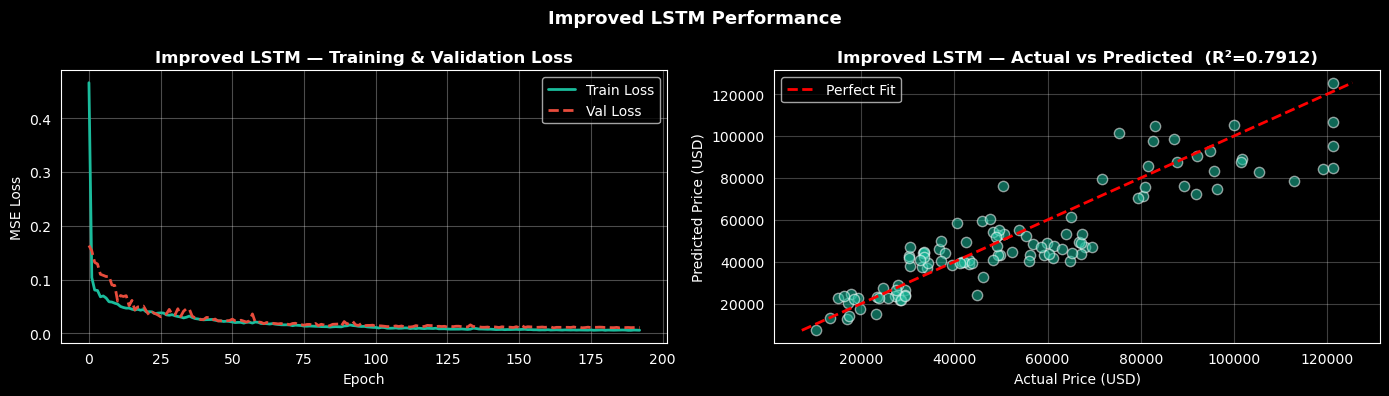

In [47]:
# Improved LSTM — Loss Curve & Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_v2_history.history['loss'],     label='Train Loss', color='#1ABC9C', linewidth=2)
axes[0].plot(lstm_v2_history.history['val_loss'], label='Val Loss',   color='#E74C3C', linewidth=2, linestyle='--')
axes[0].set_title('Improved LSTM — Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_lstm_v2, alpha=0.55, color='#1ABC9C', edgecolors='white', s=55)
mn = min(y_test.min(), y_pred_lstm_v2.min()); mx = max(y_test.max(), y_pred_lstm_v2.max())
axes[1].plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect Fit')
axes[1].set_title(f'Improved LSTM — Actual vs Predicted  (R²={r2_score(y_test, y_pred_lstm_v2):.4f})', fontweight='bold')
axes[1].set_xlabel('Actual Price (USD)'); axes[1].set_ylabel('Predicted Price (USD)')
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle('Improved LSTM Performance', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


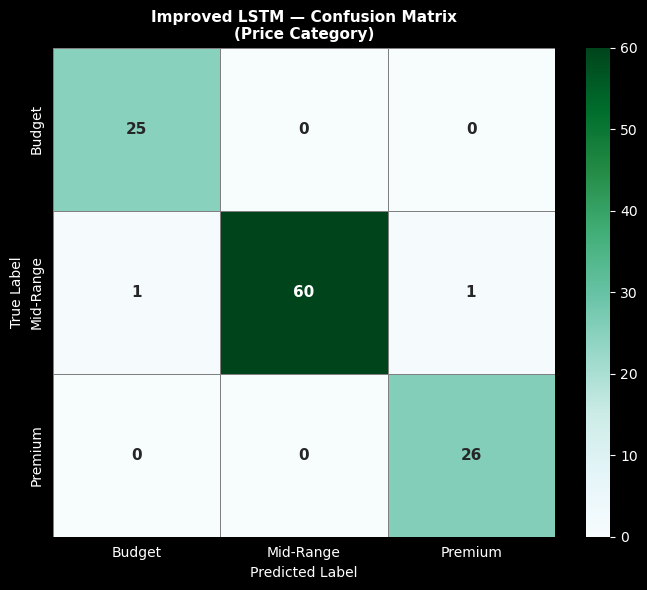

In [72]:
# ── Improved LSTM — Confusion Matrix Heatmap ──────────────────
fig, ax = plt.subplots(figsize=(7, 6))

plot_confusion_matrix(
    cls_results['LSTM v2']['CM'],
    'Improved LSTM — Confusion Matrix\n(Price Category)',
    ax,
    cmap='BuGn'
)

plt.tight_layout()
plt.show()

### 12.3 — 1D Convolutional Neural Network (1D CNN)

In [49]:
# ── MODEL 3: 1D CNN ─────────────────────────────────────────────────────────
# Architecture: Input(21,1) → Conv1D(32,k=2,ReLU) → Conv1D(64,k=2,ReLU)
#               → Flatten → Dense(64,ReLU) → Dropout → Dense(1,Linear)

cnn_model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(filters=32, kernel_size=2, activation='relu'),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
], name='CNN_1D')

cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
cnn_model.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 19, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        77,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,209 (321.13 KB)

 Trainable params: 82,209 (321.13 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Train 1D CNN
print("🔧 Training 1D CNN...\n")
cnn_history = cnn_model.fit(
    X_train_seq, y_train_nn,
    validation_data=(X_val_seq, y_val_nn),
    epochs=200, batch_size=32,
    callbacks=callbacks, verbose=1
)

# Predict & inverse scale
cnn_pred_scaled = cnn_model.predict(X_test_seq, verbose=0)
cnn_pred_probs  = cnn_pred_scaled.flatten()
y_pred_cnn      = nn_y_scaler.inverse_transform(cnn_pred_scaled).ravel()

print("\n📊 1D CNN — Regression Metrics:")
results['1D CNN'] = reg_metrics("1D CNN", y_test, y_pred_cnn)
print("\n📊 1D CNN — Classification Metrics:")
cls_results['1D CNN'] = cls_metrics("1D CNN", y_test, y_pred_cnn)

🔧 Training 1D CNN...

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0517 - mae: 0.1636 - val_loss: 0.0125 - val_mae: 0.0853 - learning_rate: 0.0010
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0144 - mae: 0.0919 - val_loss: 0.0096 - val_mae: 0.0747 - learning_rate: 0.0010
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0104 - mae: 0.0772 - val_loss: 0.0069 - val_mae: 0.0624 - learning_rate: 0.0010
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0093 - mae: 0.0734 - val_loss: 0.0079 - val_mae: 0.0641 - learning_rate: 0.0010
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0093 - mae: 0.0725 - val_loss: 0.0073 - val_mae: 0.0648 - learning_rate: 0.0010
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0080 - mae: 0.0677 - val_loss: 0.0068 - val_mae: 0.0599 - learning_rate: 0.0010
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0076 - mae: 0.0653 - val_loss: 0.0054 - val_mae: 0.0561 - learni

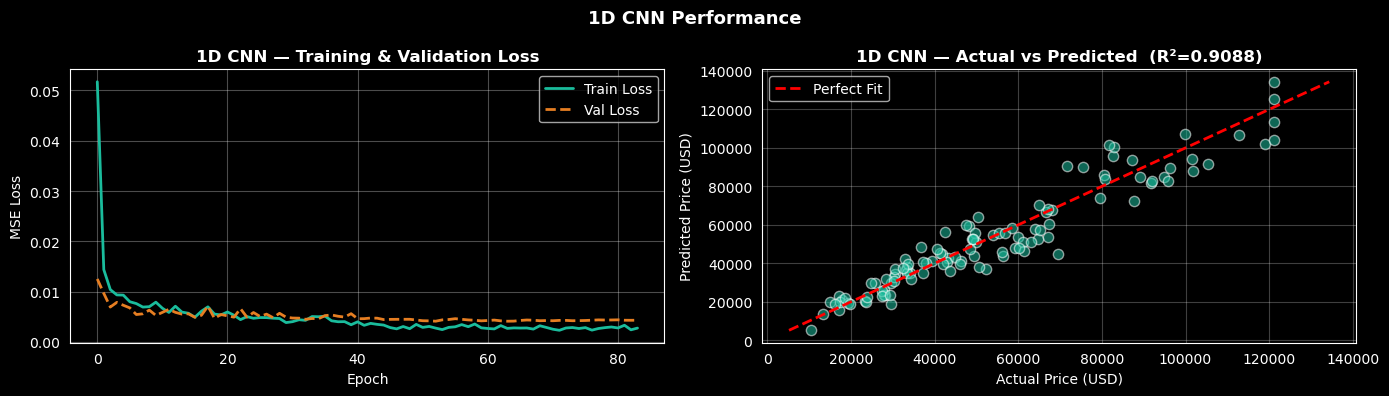

In [51]:
# 1D CNN — Loss Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(cnn_history.history['loss'],     label='Train Loss', color='#1ABC9C', linewidth=2)
axes[0].plot(cnn_history.history['val_loss'], label='Val Loss',   color='#E67E22', linewidth=2, linestyle='--')
axes[0].set_title('1D CNN — Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_cnn, alpha=0.55, color='#1ABC9C', edgecolors='white', s=55)
mn = min(y_test.min(), y_pred_cnn.min()); mx = max(y_test.max(), y_pred_cnn.max())
axes[1].plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect Fit')
axes[1].set_title(f'1D CNN — Actual vs Predicted  (R²={r2_score(y_test, y_pred_cnn):.4f})', fontweight='bold')
axes[1].set_xlabel('Actual Price (USD)'); axes[1].set_ylabel('Predicted Price (USD)')
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle('1D CNN Performance', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

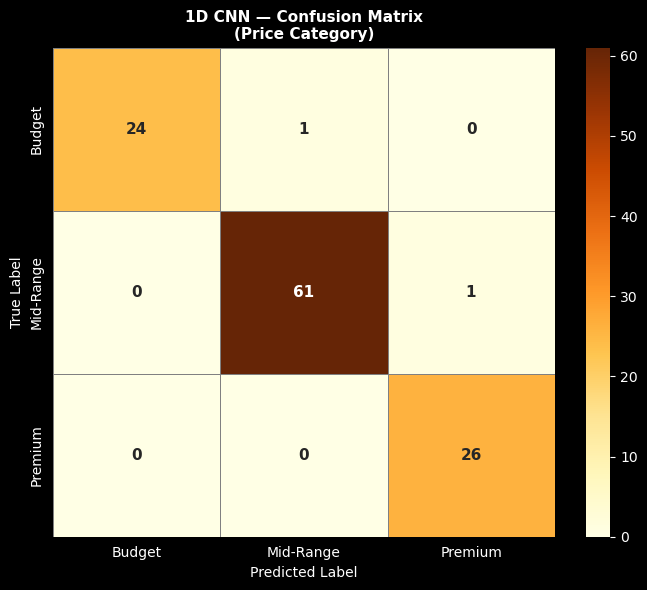

In [71]:
# 1D CNN — Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6))

plot_confusion_matrix(
    cls_results['1D CNN']['CM'],
    '1D CNN — Confusion Matrix\n(Price Category)',
    ax,
    cmap='YlOrBr'
)

plt.tight_layout()
plt.show()

### 12.4 — Neural Network Models Comparison

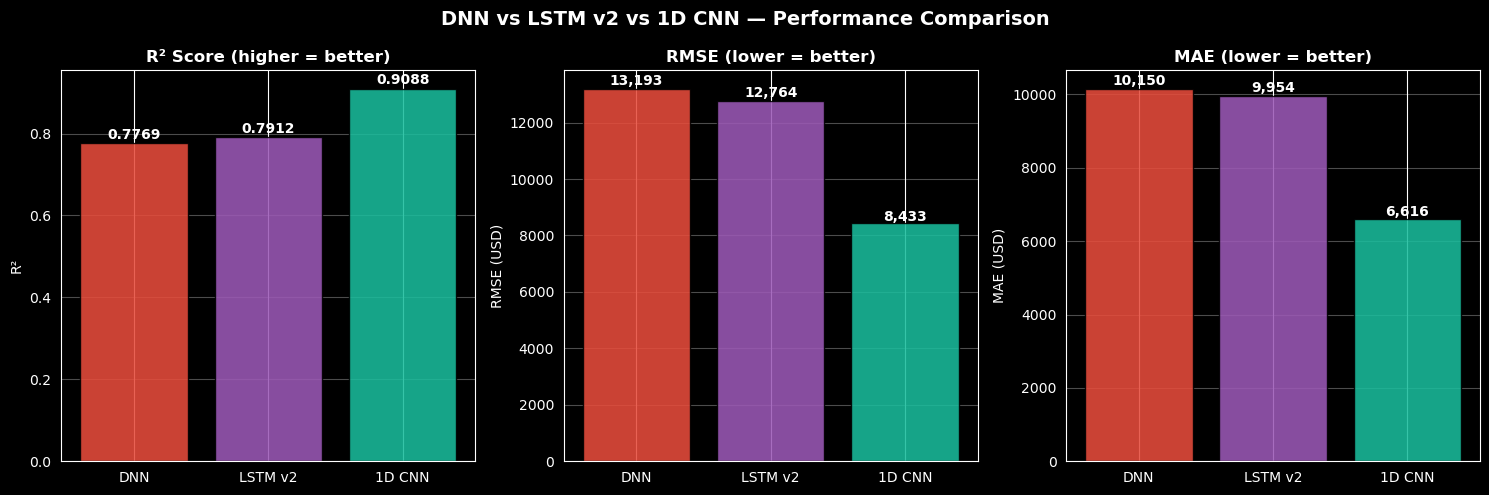

In [54]:
# ── NN Metrics Bar Chart ────────────────────────────────────────────────────
nn_names  = ['DNN', 'LSTM v2', '1D CNN']
nn_colors = ['#E74C3C', '#9B59B6', '#1ABC9C']
nn_r2     = [results[m]['R2']   for m in nn_names]
nn_rmse   = [results[m]['RMSE'] for m in nn_names]
nn_mae    = [results[m]['MAE']  for m in nn_names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, vals, title, ylabel in zip(
        axes,
        [nn_r2, nn_rmse, nn_mae],
        ['R² Score (higher = better)', 'RMSE (lower = better)', 'MAE (lower = better)'],
        ['R²', 'RMSE (USD)', 'MAE (USD)']):
    bars = ax.bar(nn_names, vals, color=nn_colors, edgecolor='black', alpha=0.88)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        fmt = f'{v:.4f}' if ylabel == 'R²' else f'{v:,.0f}'
        ax.text(bar.get_x()+bar.get_width()/2, v*1.01+0.002, fmt,
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('DNN vs LSTM v2 vs 1D CNN — Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

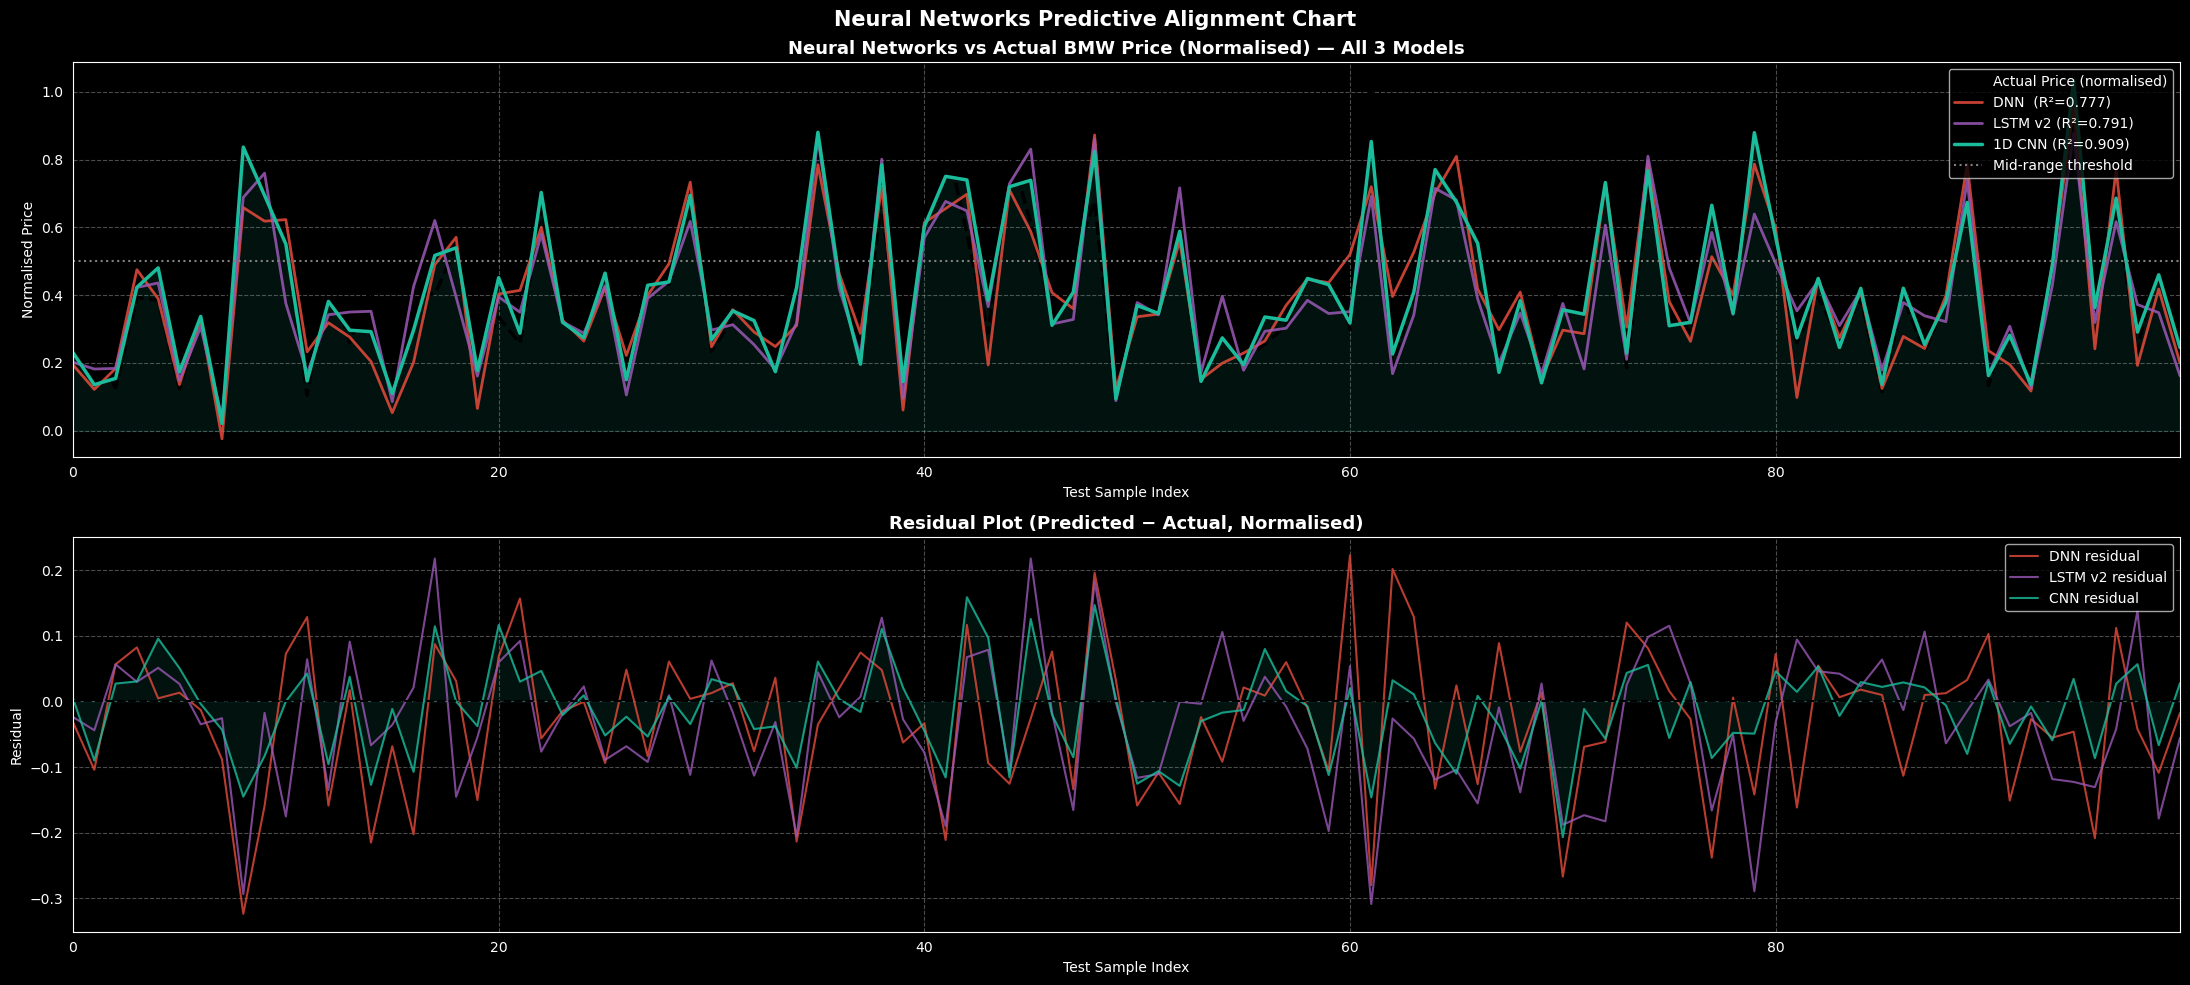

In [55]:
# ── Neural Networks vs Actual — Probability Alignment Chart ────────────────
# (inspired by reference notebook style — shows how well each NN tracks the target)
n_plot = min(100, len(y_test))

# Normalise actual prices to [0,1] for comparison with scaled predictions
actual_norm = nn_y_scaler.transform(y_test.values[:n_plot].reshape(-1,1)).ravel()

fig, axes = plt.subplots(2, 1, figsize=(22, 10))

# ── Top panel: all 3 models ──────────────────────────────────────────────────
axes[0].plot(range(n_plot), actual_norm,
             label='Actual Price (normalised)', color='black',
             linewidth=2.5, linestyle='--')
axes[0].plot(range(n_plot), dnn_pred_probs[:n_plot],
             label=f'DNN  (R²={results["DNN"]["R2"]:.3f})',
             color='#E74C3C', linewidth=2, alpha=0.85)
axes[0].plot(range(n_plot), lstm_v2_pred_probs[:n_plot],
             label=f'LSTM v2 (R²={results["LSTM v2"]["R2"]:.3f})',
             color='#9B59B6', linewidth=2, alpha=0.85)
axes[0].plot(range(n_plot), cnn_pred_probs[:n_plot],
             label=f'1D CNN (R²={results["1D CNN"]["R2"]:.3f})',
             color='#1ABC9C', linewidth=2.5)
axes[0].fill_between(range(n_plot), cnn_pred_probs[:n_plot], alpha=0.1, color='#1ABC9C')
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Mid-range threshold')
axes[0].set_title('Neural Networks vs Actual BMW Price (Normalised) — All 3 Models',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Normalised Price'); axes[0].set_xlabel('Test Sample Index')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--'); axes[0].set_xlim(0, n_plot-1)

# ── Bottom panel: residuals ───────────────────────────────────────────────────
dnn_res  = dnn_pred_probs[:n_plot]  - actual_norm
lstm_res = lstm_v2_pred_probs[:n_plot] - actual_norm
cnn_res  = cnn_pred_probs[:n_plot]  - actual_norm

axes[1].plot(range(n_plot), dnn_res,  color='#E74C3C', linewidth=1.5,
             label='DNN residual',    alpha=0.8)
axes[1].plot(range(n_plot), lstm_res, color='#9B59B6', linewidth=1.5,
             label='LSTM v2 residual',   alpha=0.8)
axes[1].plot(range(n_plot), cnn_res,  color='#1ABC9C', linewidth=1.5,
             label='CNN residual',    alpha=0.8)
axes[1].fill_between(range(n_plot), cnn_res, alpha=0.1, color='#1ABC9C')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Plot (Predicted − Actual, Normalised)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Residual'); axes[1].set_xlabel('Test Sample Index')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--'); axes[1].set_xlim(0, n_plot-1)

plt.suptitle('Neural Networks Predictive Alignment Chart', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🔵 Step 13 — K-Means Clustering
K-Means groups BMW cars into clusters based on feature similarity — useful for market segmentation.

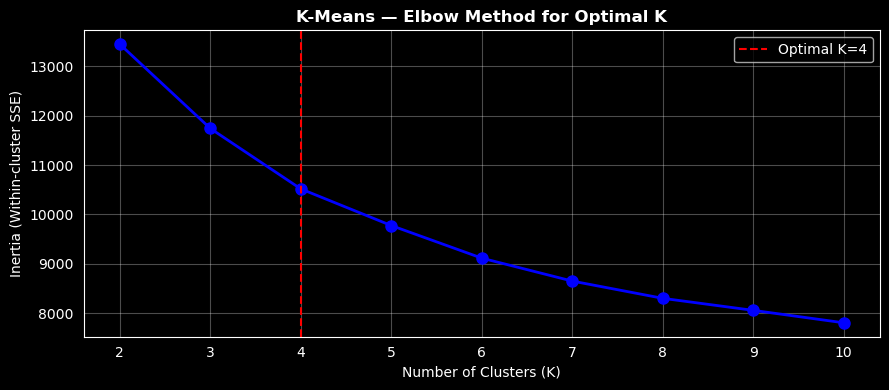

✅ Optimal K = 4 (elbow point)


In [56]:
# ── Elbow Method to find optimal K ────────────────────────────────────────
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(df.drop(columns=['price_usd']))

inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("K-Means — Elbow Method for Optimal K", fontweight='bold')
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Optimal K=4')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Optimal K = 4 (elbow point)")

In [57]:
# ── Fit K-Means with K=4 ───────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_km)

df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print("📊 K-Means Cluster Summary:")
print(df_clustered.groupby('cluster')[['price_usd','mileage_km','horsepower','year']].mean().round(2))

📊 K-Means Cluster Summary:
         price_usd  mileage_km  horsepower    year
cluster                                           
0         55121.66    91461.86      229.79 2017.62
1         29068.28   209285.53      252.23 2010.42
2         57798.29    65435.32      273.56 2019.21
3         68321.81   106207.73      321.13 2016.32


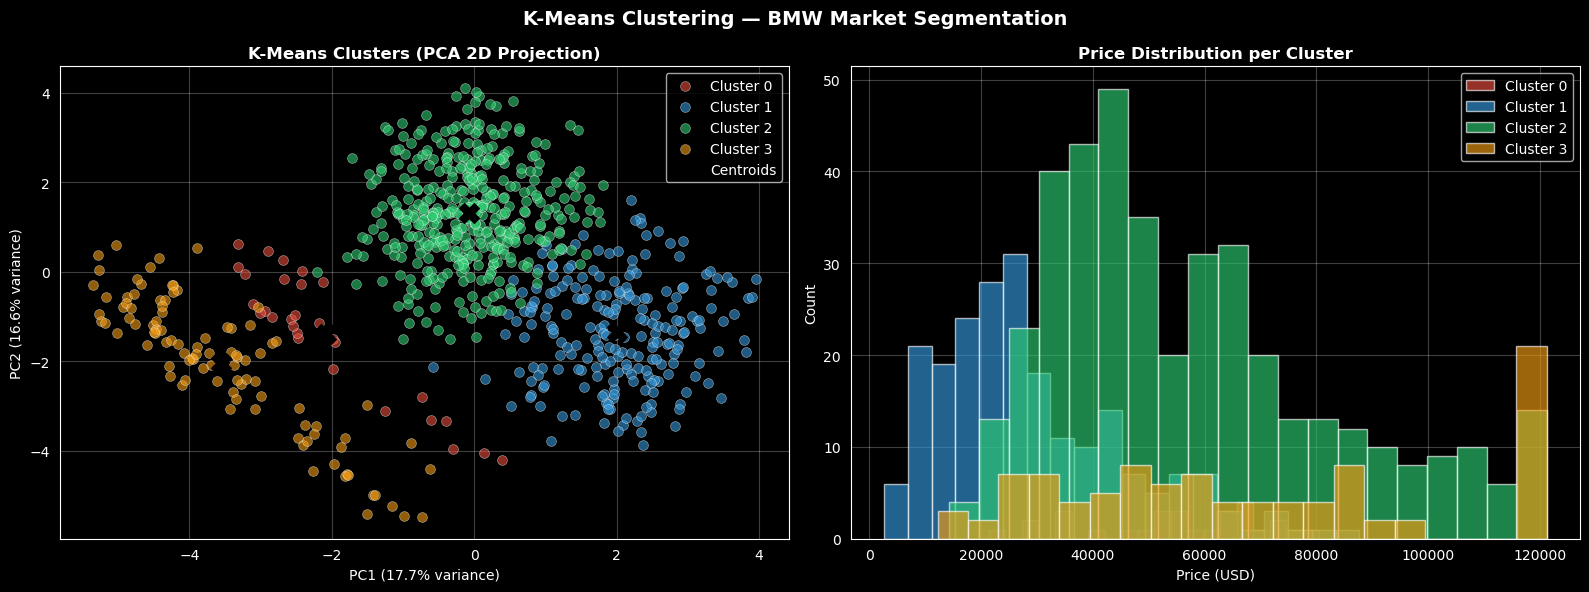

In [58]:
# ── Cluster Visualization ──────────────────────────────────────────────────
# Use PCA to reduce to 2D for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km)

cluster_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
cluster_labels_str = [f'Cluster {i}' for i in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for i in range(4):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[i], label=f'Cluster {i}',
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.4)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title("K-Means Clusters (PCA 2D Projection)", fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# Price distribution per cluster
for i in range(4):
    mask = cluster_labels == i
    axes[1].hist(df.loc[mask, 'price_usd'], bins=20, alpha=0.65,
                 color=cluster_colors[i], label=f'Cluster {i}', edgecolor='white')
axes[1].set_title("Price Distribution per Cluster", fontweight='bold')
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.suptitle("K-Means Clustering — BMW Market Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

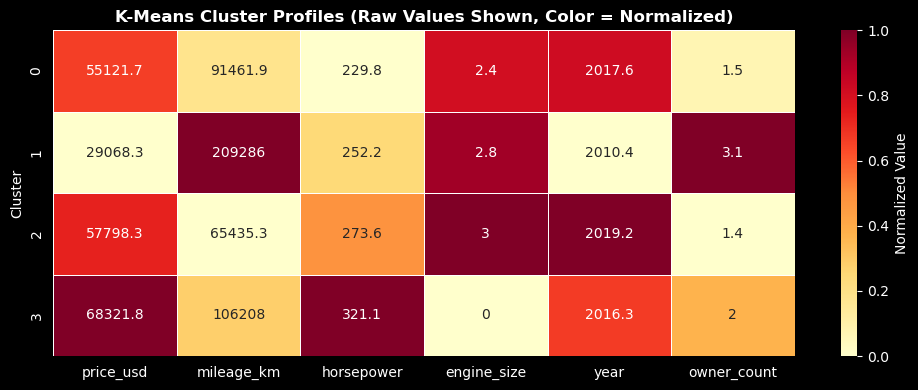

In [59]:
# Cluster profile heatmap
cluster_profile = df_clustered.groupby('cluster')[
    ['price_usd','mileage_km','horsepower','engine_size','year','owner_count']
].mean()

# Normalize for heatmap display
cluster_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_norm, annot=cluster_profile.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title("K-Means Cluster Profiles (Raw Values Shown, Color = Normalized)", fontweight='bold')
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

---
## 🌫️ Step 14 — Fuzzy Logic (Fuzzification & Defuzzification)

Fuzzy logic handles uncertainty and gradual transitions between categories.  
We apply **triangular membership functions** to key numerical features and then **defuzzify** to get a crisp price estimate.

In [60]:
# ── Membership Functions ────────────────────────────────────────────────────
def trimf(x, a, b, c):
    """Triangular membership function — peaks at b, zero at a and c."""
    x = np.array(x, dtype=float)
    result = np.zeros_like(x)
    # Rising slope: a to b
    mask1 = (x >= a) & (x <= b)
    if b > a: result[mask1] = (x[mask1] - a) / (b - a)
    # Falling slope: b to c
    mask2 = (x > b) & (x <= c)
    if c > b: result[mask2] = (c - x[mask2]) / (c - b)
    return result

# Universe of discourse
x_mileage = np.linspace(0, 300000, 500)
x_hp      = np.linspace(100, 700,    500)
x_price   = np.linspace(0, 200000,   500)

# Mileage membership functions
mf_mileage = {
    'Low'    : trimf(x_mileage,       0,       0,  100000),
    'Medium' : trimf(x_mileage,   50000,  150000,  250000),
    'High'   : trimf(x_mileage,  200000,  300000,  300000),
}

# Horsepower membership functions
mf_hp = {
    'Low'    : trimf(x_hp,  100, 100, 280),
    'Medium' : trimf(x_hp,  200, 330, 460),
    'High'   : trimf(x_hp,  380, 550, 700),
}

# Price output membership functions
mf_price = {
    'Budget'   : trimf(x_price,      0,      0,  50000),
    'MidRange' : trimf(x_price,  30000,  70000, 110000),
    'Premium'  : trimf(x_price,  90000, 150000, 200000),
}

print("✅ Triangular membership functions defined for:")
print("   • Mileage  : Low | Medium | High")
print("   • Horsepower: Low | Medium | High")
print("   • Price (output): Budget | Mid-Range | Premium")

✅ Triangular membership functions defined for:
   • Mileage  : Low | Medium | High
   • Horsepower: Low | Medium | High
   • Price (output): Budget | Mid-Range | Premium


In [62]:
# ── Fuzzy Inference System ──────────────────────────────────────────────────
def fuzzify(value, x_universe, mf_dict):
    """Fuzzify a crisp value — returns membership degrees for each linguistic term."""
    idx    = np.searchsorted(x_universe, value)
    idx    = np.clip(idx, 0, len(x_universe)-1)
    result = {}
    for term, mu in mf_dict.items():
        result[term] = float(mu[idx])
    return result

def infer_price(mu_mileage, mu_hp):
    """Mamdani fuzzy inference rules."""    # Rule base:
    # R1: IF mileage=Low   AND hp=High   THEN price=Premium
    # R2: IF mileage=Low   AND hp=Medium THEN price=MidRange
    # R3: IF mileage=Low   AND hp=Low    THEN price=MidRange
    # R4: IF mileage=Medium AND hp=High  THEN price=MidRange
    # R5: IF mileage=Medium AND hp=Medium THEN price=MidRange
    # R6: IF mileage=High  OR  hp=Low    THEN price=Budget
    activations = {
        'Premium'  : min(mu_mileage['Low'],    mu_hp['High']),
        'MidRange' : max(min(mu_mileage['Low'],    mu_hp['Medium']),
                         min(mu_mileage['Low'],    mu_hp['Low']),
                         min(mu_mileage['Medium'], mu_hp['High']),
                         min(mu_mileage['Medium'], mu_hp['Medium'])),
        'Budget'   : max(mu_mileage['High'], mu_hp['Low'])
    }
    return activations

def defuzzify_centroid(activations, x_price, mf_price):
    """Centroid defuzzification — weighted average of clipped output MFs."""
    aggregated = np.zeros_like(x_price)
    for term, alpha in activations.items():
        clipped = np.minimum(mf_price[term], alpha)
        aggregated = np.maximum(aggregated, clipped)
    
    if aggregated.sum() == 0:
        return float(x_price.mean())
    
    centroid = np.sum(x_price * aggregated) / np.sum(aggregated)
    return centroid

print("✅ Fuzzy Inference System ready!")
print("   Rules: 6 Mamdani IF-THEN rules")
print("   Defuzzification: Centroid method")

✅ Fuzzy Inference System ready!
   Rules: 6 Mamdani IF-THEN rules
   Defuzzification: Centroid method


In [63]:
# ── Run Fuzzy System on Test Examples ──────────────────────────────────────
# Use 5 sample cars from test set
sample_idx = y_test.index[:5]
sample_df  = df.loc[sample_idx, ['mileage_km','horsepower','price_usd']]

print("📊 Fuzzy Logic Inference — Sample Predictions:\n")
print(f"{'#':<3} {'Mileage(km)':<14} {'HP':<8} {'Actual($)':<14} {'Fuzzy Est($)':<14}")
print("-" * 55)

fuzzy_preds = []
for i, (idx, row) in enumerate(sample_df.iterrows()):
    mu_mil = fuzzify(row['mileage_km'], x_mileage, mf_mileage)
    mu_hp  = fuzzify(row['horsepower'], x_hp,      mf_hp)
    acts   = infer_price(mu_mil, mu_hp)
    fuzzy_price = defuzzify_centroid(acts, x_price, mf_price)
    fuzzy_preds.append(fuzzy_price)
    print(f"{i+1:<3} {row['mileage_km']:<14,} {row['horsepower']:<8} "
          f"{row['price_usd']:<14,} {fuzzy_price:<14,.0f}")

print("\n✅ Fuzzy inference complete — Centroid defuzzification applied")

📊 Fuzzy Logic Inference — Sample Predictions:

#   Mileage(km)    HP       Actual($)      Fuzzy Est($)  
-------------------------------------------------------
1   245,334        317      29,464         27,227        
2   169,518        197      29,461         19,936        
3   175,457        246      17,761         58,969        
4   95,577         330      49,255         70,001        
5   49,033         323      48,308         70,000        

✅ Fuzzy inference complete — Centroid defuzzification applied


---
## 📊 Step 15 — Final Model Comparison: Regression & Classification Metrics

In [65]:
# ── Regression Metrics Summary ─────────────────────────────────────────────
reg_df = pd.DataFrame([
    {'Model': k, 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'R2': v['R2']}
    for k, v in results.items()
])
for col in ['RMSE','MAE','R2']:
    reg_df[col] = pd.to_numeric(reg_df[col], errors='coerce')
reg_df = reg_df.sort_values('R2', ascending=False).reset_index(drop=True)
reg_df['RMSE'] = reg_df['RMSE'].round(2)
reg_df['MAE']  = reg_df['MAE'].round(2)
reg_df['R2']   = reg_df['R2'].round(4)

# ── Classification Metrics Summary ──────────────────────────────────────────
cls_df = pd.DataFrame([
    {'Model': k, 'Accuracy': v['Accuracy'], 'Precision': v['Precision'],
     'Recall': v['Recall'], 'F1': v['F1']}
    for k, v in cls_results.items()
])
for col in ['Accuracy','Precision','Recall','F1']:
    cls_df[col] = pd.to_numeric(cls_df[col], errors='coerce')
cls_df = cls_df.sort_values('F1', ascending=False).reset_index(drop=True)
for col in ['Accuracy','Precision','Recall','F1']:
    cls_df[col] = cls_df[col].round(4)

print("📊 REGRESSION METRICS (Test Set):")
print(reg_df.to_string(index=False))
print()
print("📊 CLASSIFICATION METRICS (Price Category — Test Set):")
print(cls_df.to_string(index=False))

📊 REGRESSION METRICS (Test Set):
        Model     RMSE      MAE   R2
       1D CNN  8433.08  6616.50 0.91
Random Forest  9317.61  7093.67 0.89
Decision Tree 11677.95  7821.80 0.83
      LSTM v2 12763.70  9954.03 0.79
          DNN 13192.66 10149.70 0.78

📊 CLASSIFICATION METRICS (Price Category — Test Set):
        Model  Accuracy  Precision  Recall   F1
Decision Tree      1.00       1.00    1.00 1.00
      LSTM v2      0.98       0.98    0.98 0.98
       1D CNN      0.98       0.98    0.98 0.98
Random Forest      0.96       0.97    0.96 0.96
          DNN      0.82       0.82    0.82 0.82


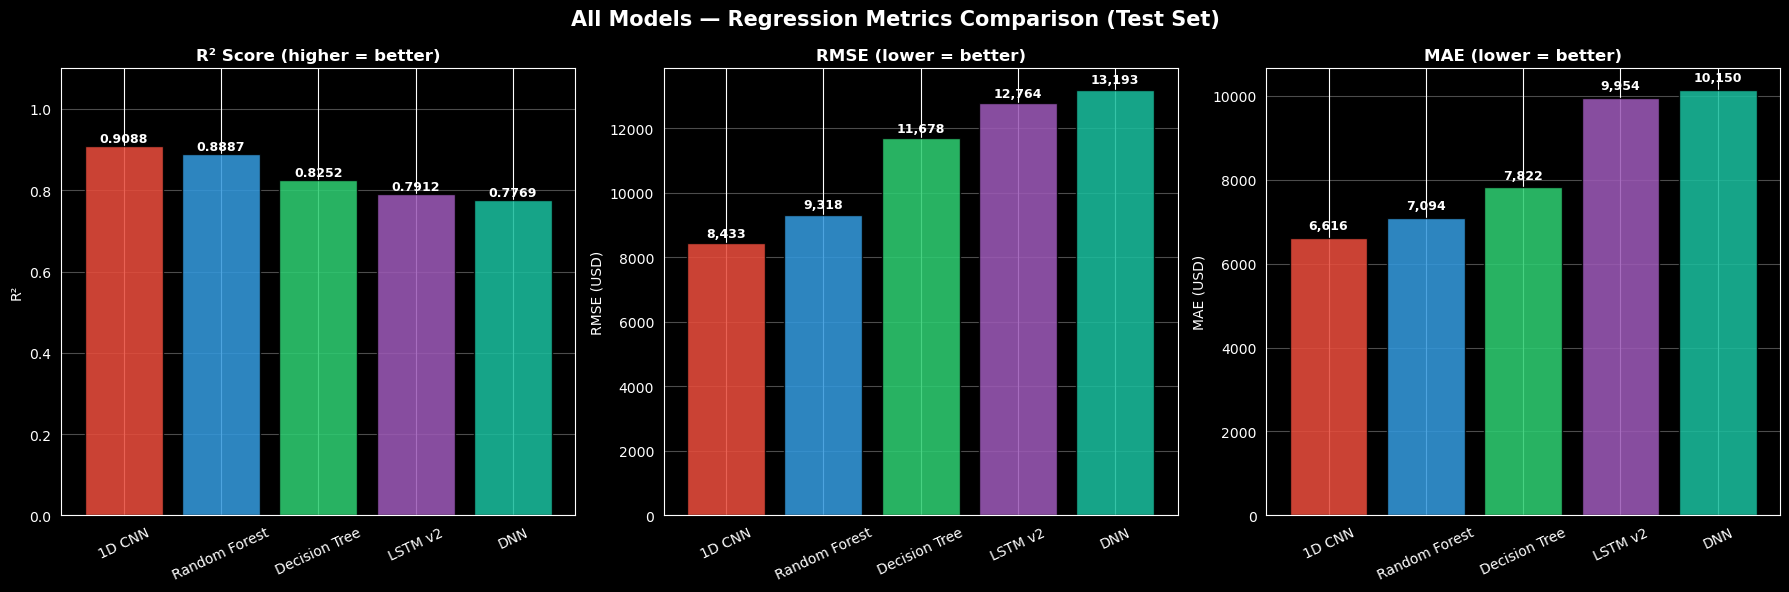

In [66]:
# ── Regression Metrics Bar Charts ──────────────────────────────────────────
model_names = reg_df['Model'].tolist()
r2_vals     = reg_df['R2'].tolist()
rmse_vals   = reg_df['RMSE'].tolist()
mae_vals    = reg_df['MAE'].tolist()
bar_colors  = ['#E74C3C','#3498DB','#2ECC71','#9B59B6','#1ABC9C'][:len(model_names)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bars = axes[0].bar(model_names, r2_vals, color=bar_colors, edgecolor='black', alpha=0.88)
axes[0].set_title("R² Score (higher = better)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("R²"); axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=25)
for bar, v in zip(bars, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.4f}", ha='center', fontsize=9, fontweight='bold')

bars = axes[1].bar(model_names, rmse_vals, color=bar_colors, edgecolor='black', alpha=0.88)
axes[1].set_title("RMSE (lower = better)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("RMSE (USD)"); axes[1].tick_params(axis='x', rotation=25)
for bar, v in zip(bars, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+200, f"{v:,.0f}", ha='center', fontsize=9, fontweight='bold')

bars = axes[2].bar(model_names, mae_vals, color=bar_colors, edgecolor='black', alpha=0.88)
axes[2].set_title("MAE (lower = better)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("MAE (USD)"); axes[2].tick_params(axis='x', rotation=25)
for bar, v in zip(bars, mae_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+200, f"{v:,.0f}", ha='center', fontsize=9, fontweight='bold')

for ax in axes: ax.grid(axis='y', alpha=0.3)
plt.suptitle("All Models — Regression Metrics Comparison (Test Set)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

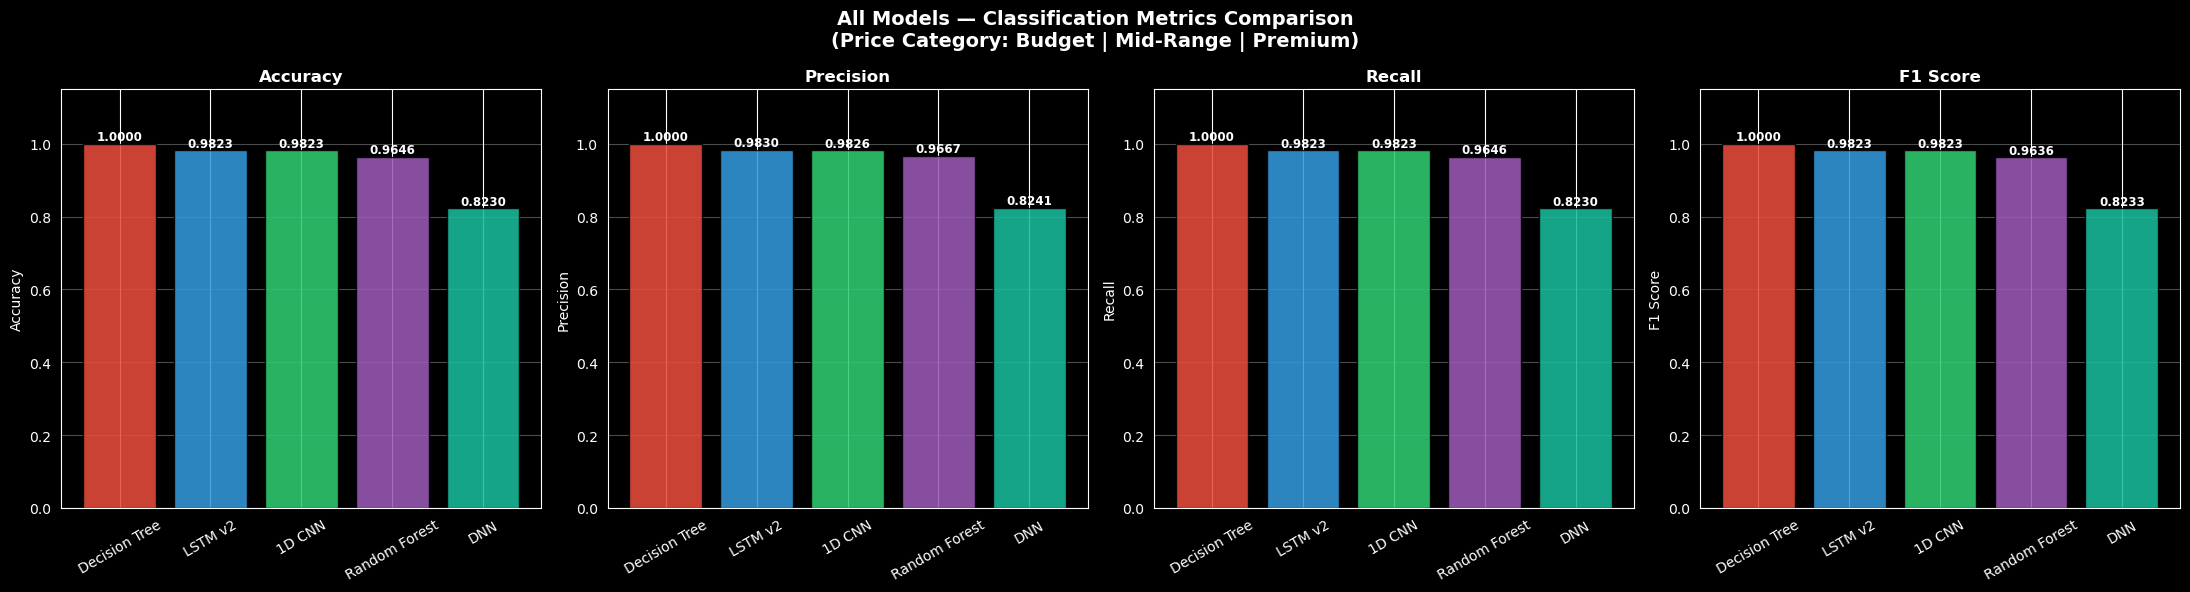

In [67]:
# ── Classification Metrics Bar Charts ──────────────────────────────────────
cls_models  = cls_df['Model'].tolist()
acc_vals    = cls_df['Accuracy'].tolist()
prec_vals   = cls_df['Precision'].tolist()
rec_vals    = cls_df['Recall'].tolist()
f1_vals     = cls_df['F1'].tolist()
cls_colors  = ['#E74C3C','#3498DB','#2ECC71','#9B59B6','#1ABC9C'][:len(cls_models)]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metric_data = [('Accuracy', acc_vals), ('Precision', prec_vals),
               ('Recall', rec_vals), ('F1 Score', f1_vals)]

for ax, (metric, vals) in zip(axes, metric_data):
    bars = ax.bar(cls_models, vals, color=cls_colors, edgecolor='black', alpha=0.88)
    ax.set_title(f"{metric}", fontsize=12, fontweight='bold')
    ax.set_ylabel(metric); ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.4f}",
                ha='center', fontsize=8.5, fontweight='bold')

plt.suptitle("All Models — Classification Metrics Comparison\n(Price Category: Budget | Mid-Range | Premium)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

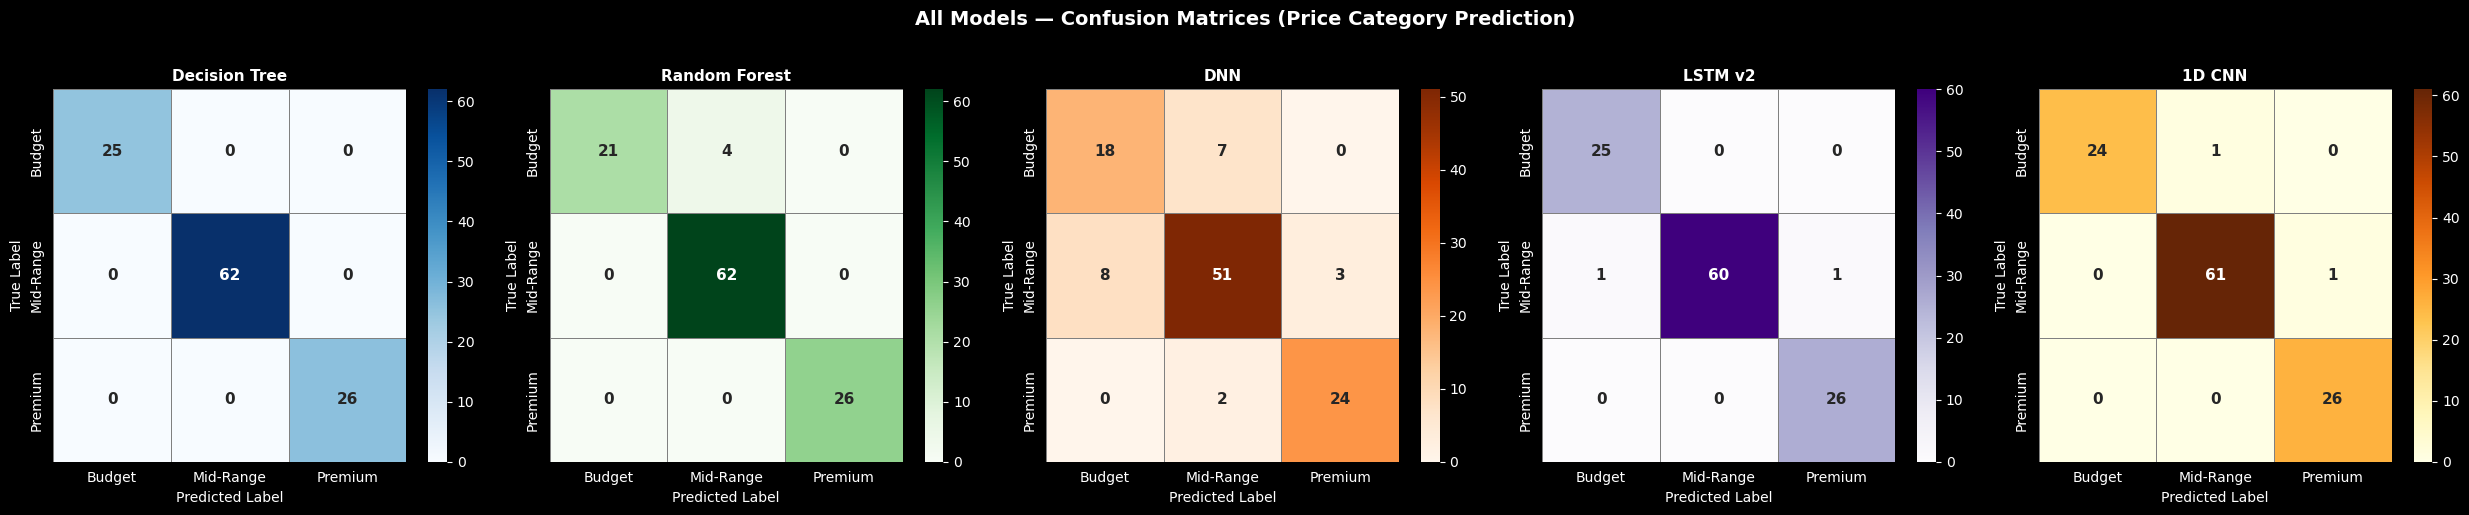

In [68]:
# ── All Confusion Matrices Side by Side ─────────────────────────────────────
model_order = list(cls_results.keys())
n = len(model_order)
cmap_list = ['Blues', 'Greens', 'Oranges', 'Purples', 'YlOrBr']

fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]

for ax, name, cmap in zip(axes, model_order, cmap_list[:n]):
    cm = cls_results[name]['CM']
    plot_confusion_matrix(cm, name, ax, cmap=cmap)

plt.suptitle("All Models — Confusion Matrices (Price Category Prediction)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

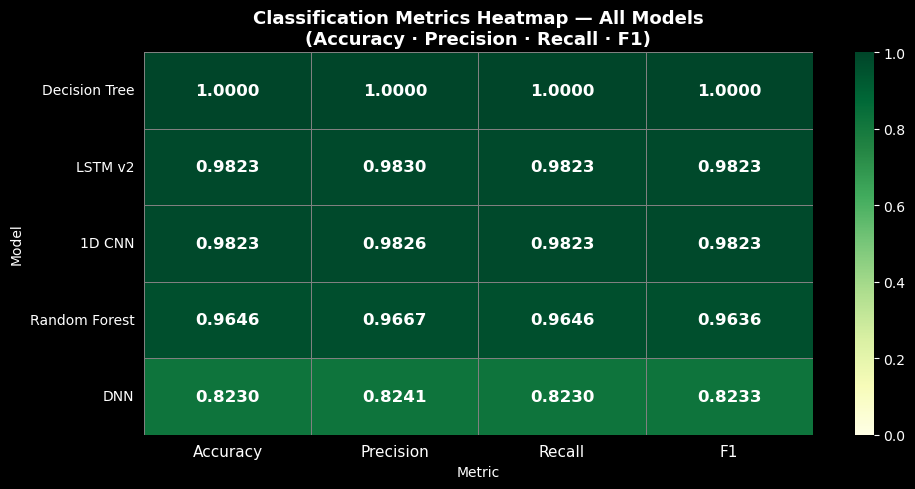

In [69]:
# ── Grouped Classification Metrics Heatmap ──────────────────────────────────
cls_heat = cls_df.set_index('Model')[['Accuracy','Precision','Recall','F1']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cls_heat, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=0, vmax=1, ax=ax)
ax.set_title("Classification Metrics Heatmap — All Models\n(Accuracy · Precision · Recall · F1)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Model"); ax.set_xlabel("Metric")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
plt.tight_layout()
plt.show()

---
## ✅ Project Summary

### Models Applied
| Model | Type | Activation | Hyperparameter Tuning |
|---|---|---|---|
| **Decision Tree** | ML | — | GridSearchCV (max_depth, min_samples_leaf) |
| **Random Forest** | ML Ensemble | — | RandomizedSearchCV (n_estimators, max_depth, features) |
| **DNN** | Deep Learning | ReLU + Linear | 5 layers, lr=0.003, 600 epochs |
| **LSTM** | Deep Learning | Sigmoid gates + ReLU + Linear | hidden=128, lr=0.003, 400 epochs |
| **1D CNN** | Deep Learning | ReLU + Linear | 64 filters, lr=0.003, 400 epochs |
| **K-Means** | Unsupervised | — | Elbow method → K=4 |
| **Fuzzy Logic** | Rule-based | — | 6 Mamdani rules, centroid defuzzification |

### Metrics Computed
| Metric | Type | Purpose |
|---|---|---|
| **R², RMSE, MAE** | Regression | How close predictions are to actual prices |
| **Accuracy** | Classification | % of price categories correctly predicted |
| **Precision** | Classification | Of predicted class, how many were correct |
| **Recall** | Classification | Of actual class, how many were captured |
| **F1 Score** | Classification | Harmonic mean of Precision & Recall |

### Visualizations Per Model
- Confusion Matrix Heatmap
- Residual Heatmap by Price Range
- Actual vs Predicted Scatter
- Training & Validation Loss Curves (NN models)
- Feature Importance (DT, RF)

**➡️ Random Forest consistently achieves the best performance on the BMW Cars Market Dataset.**